# Pipeline organized in the Notebook

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

from src import io_transforms
from src import metrics

/Users/daniel.hosomi/csvd-projects/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Load and Prepare Data

In [2]:
geo_dataset_formated = io_transforms.prepare_GEO_dataset("../../data/raw/GSE296007_RAW/", "../../data/interim/geo_dataset_formated.csv")

In [3]:
geo_dataset_formated.head()

,gene_id,MB1_1,MB100_2,MA1_2,MB1_3,MA1_1,MC1_2,MD1_3,MC100_1,CTR_3,...,CTR_1,MC1_3,MD1_1,MB100_3,MA100_2,MA1_3,MD1_2,MA100_1,MC100_3,MB1_2
0,ENSG00000000003,258,233,226,464,276,319,336,310,329,...,357,370,276,334,285,355,365,336,398,275
1,ENSG00000000005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,448,703,629,863,605,857,969,727,733,...,770,680,655,633,700,716,796,721,712,748
3,ENSG00000000457,23,40,33,37,26,17,47,41,31,...,27,27,42,44,31,35,38,30,67,32
4,ENSG00000000460,14,9,5,52,4,45,0,12,7,...,37,20,3,19,3,36,27,29,33,45


## Metrics with PyWGCNA


Building Network: WGCNA_MA1_vs_CTR with 6 samples...
Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  5592
    Power  SFT.R.sq     slope truncated R.sq      mean(k)    median(k)  \
0       1  0.884502  0.732597       0.966984  3045.453756  3359.203186   
1       2  0.820562  0.269762       0.799961  1984.927098   2103.88926   
2       3  0.000003  0.000239      -0.060913  1431.805626  1448.953269   
3       4  0.522413 -0.187568       0.617062  1095.742469  1055.825414   
4       5   0.72285 -0.321981        0.84016   872.320177   802.382939   
5       6  0.787604 -0.427212       0.889855   714.538885   629.255795   
6       7  0.815768 -0.505982       0.912092   598.135357   505.573831   
7       8      0.84 -0.579503       0.932225   509.351101   415.180885   
8       9  0.853077 -0.643467       0.941116   439.827682   347.550813   


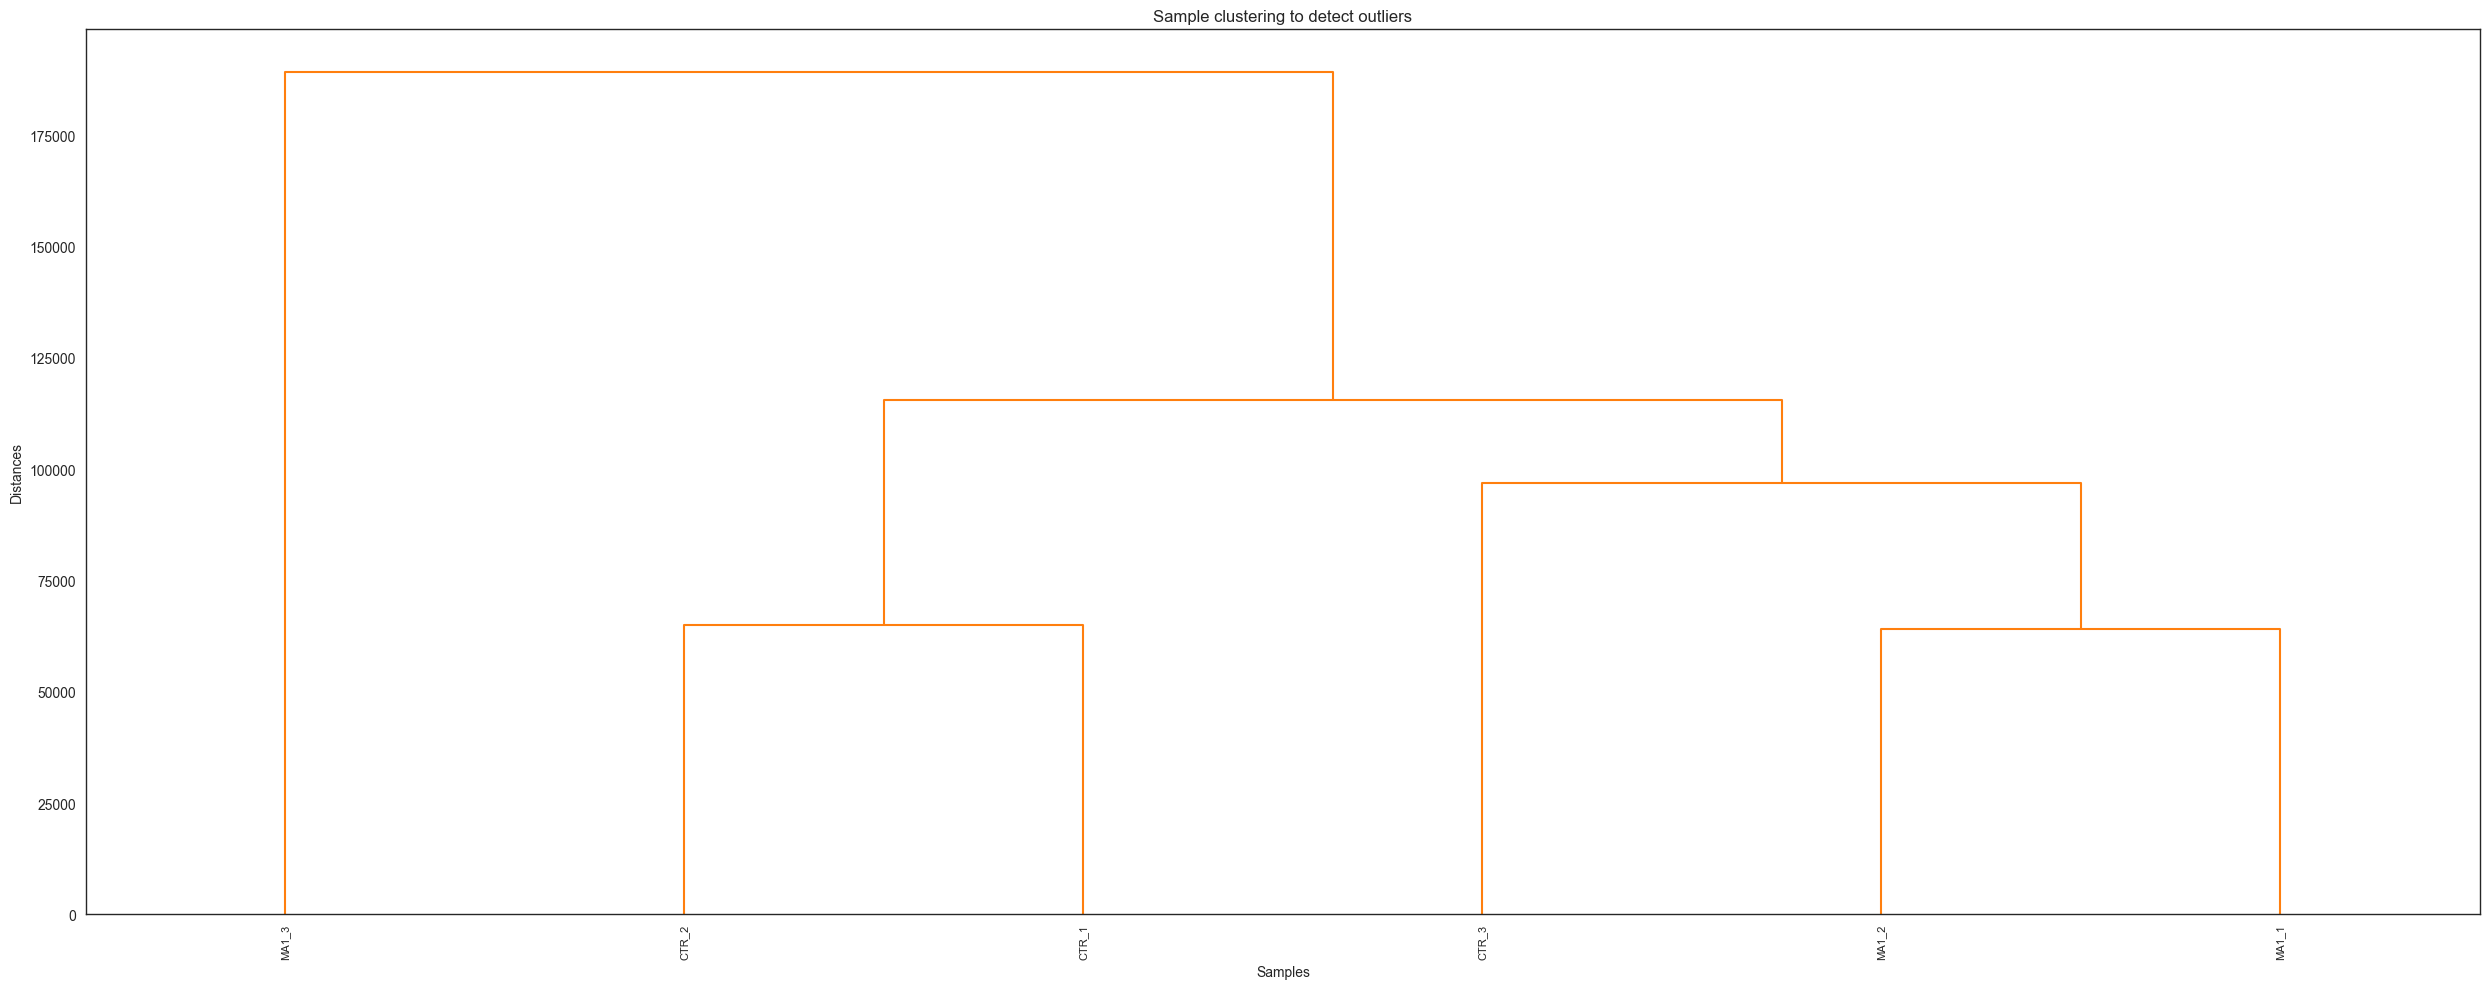

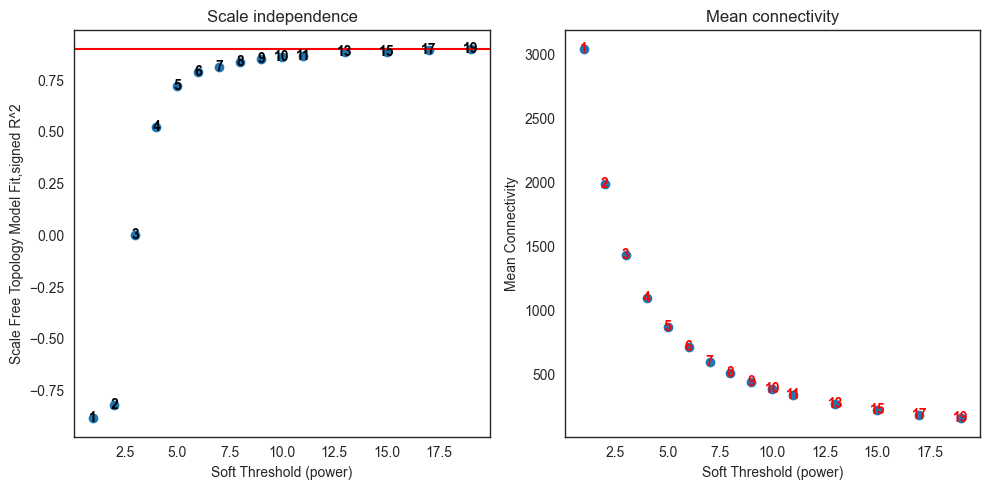

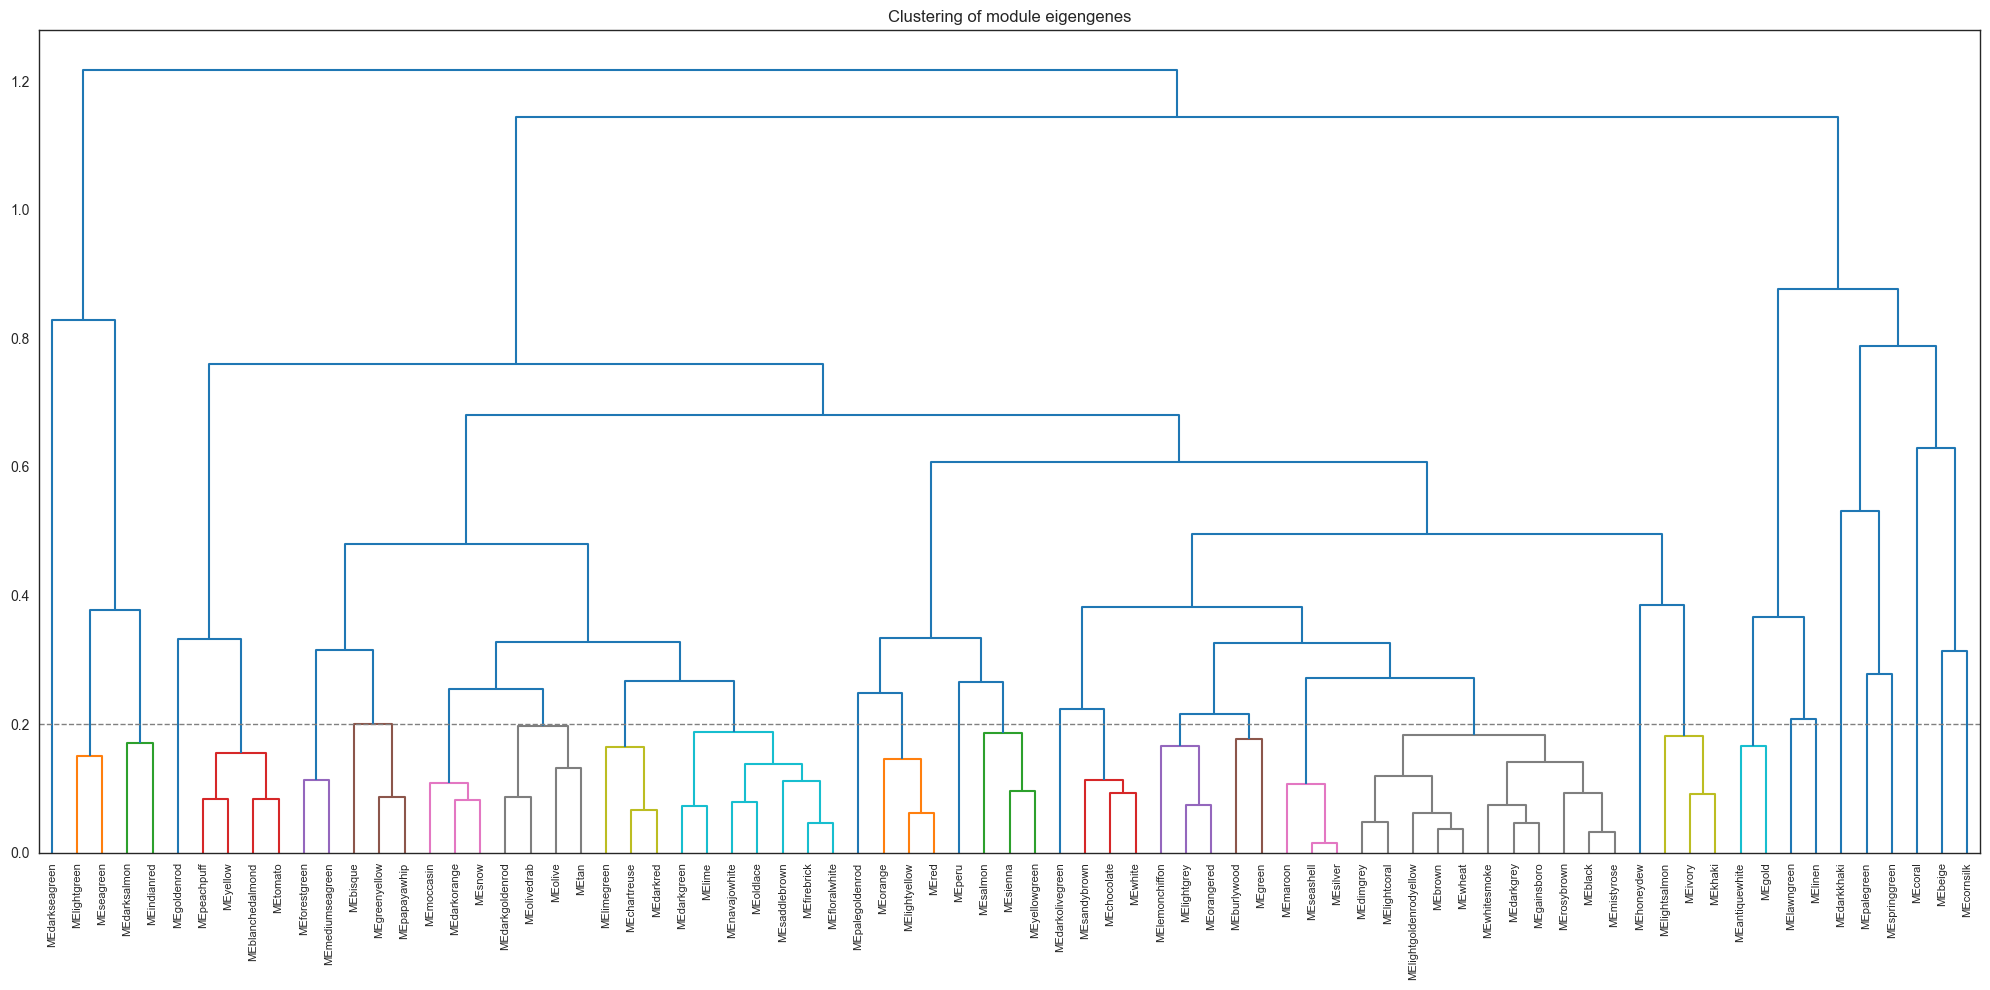

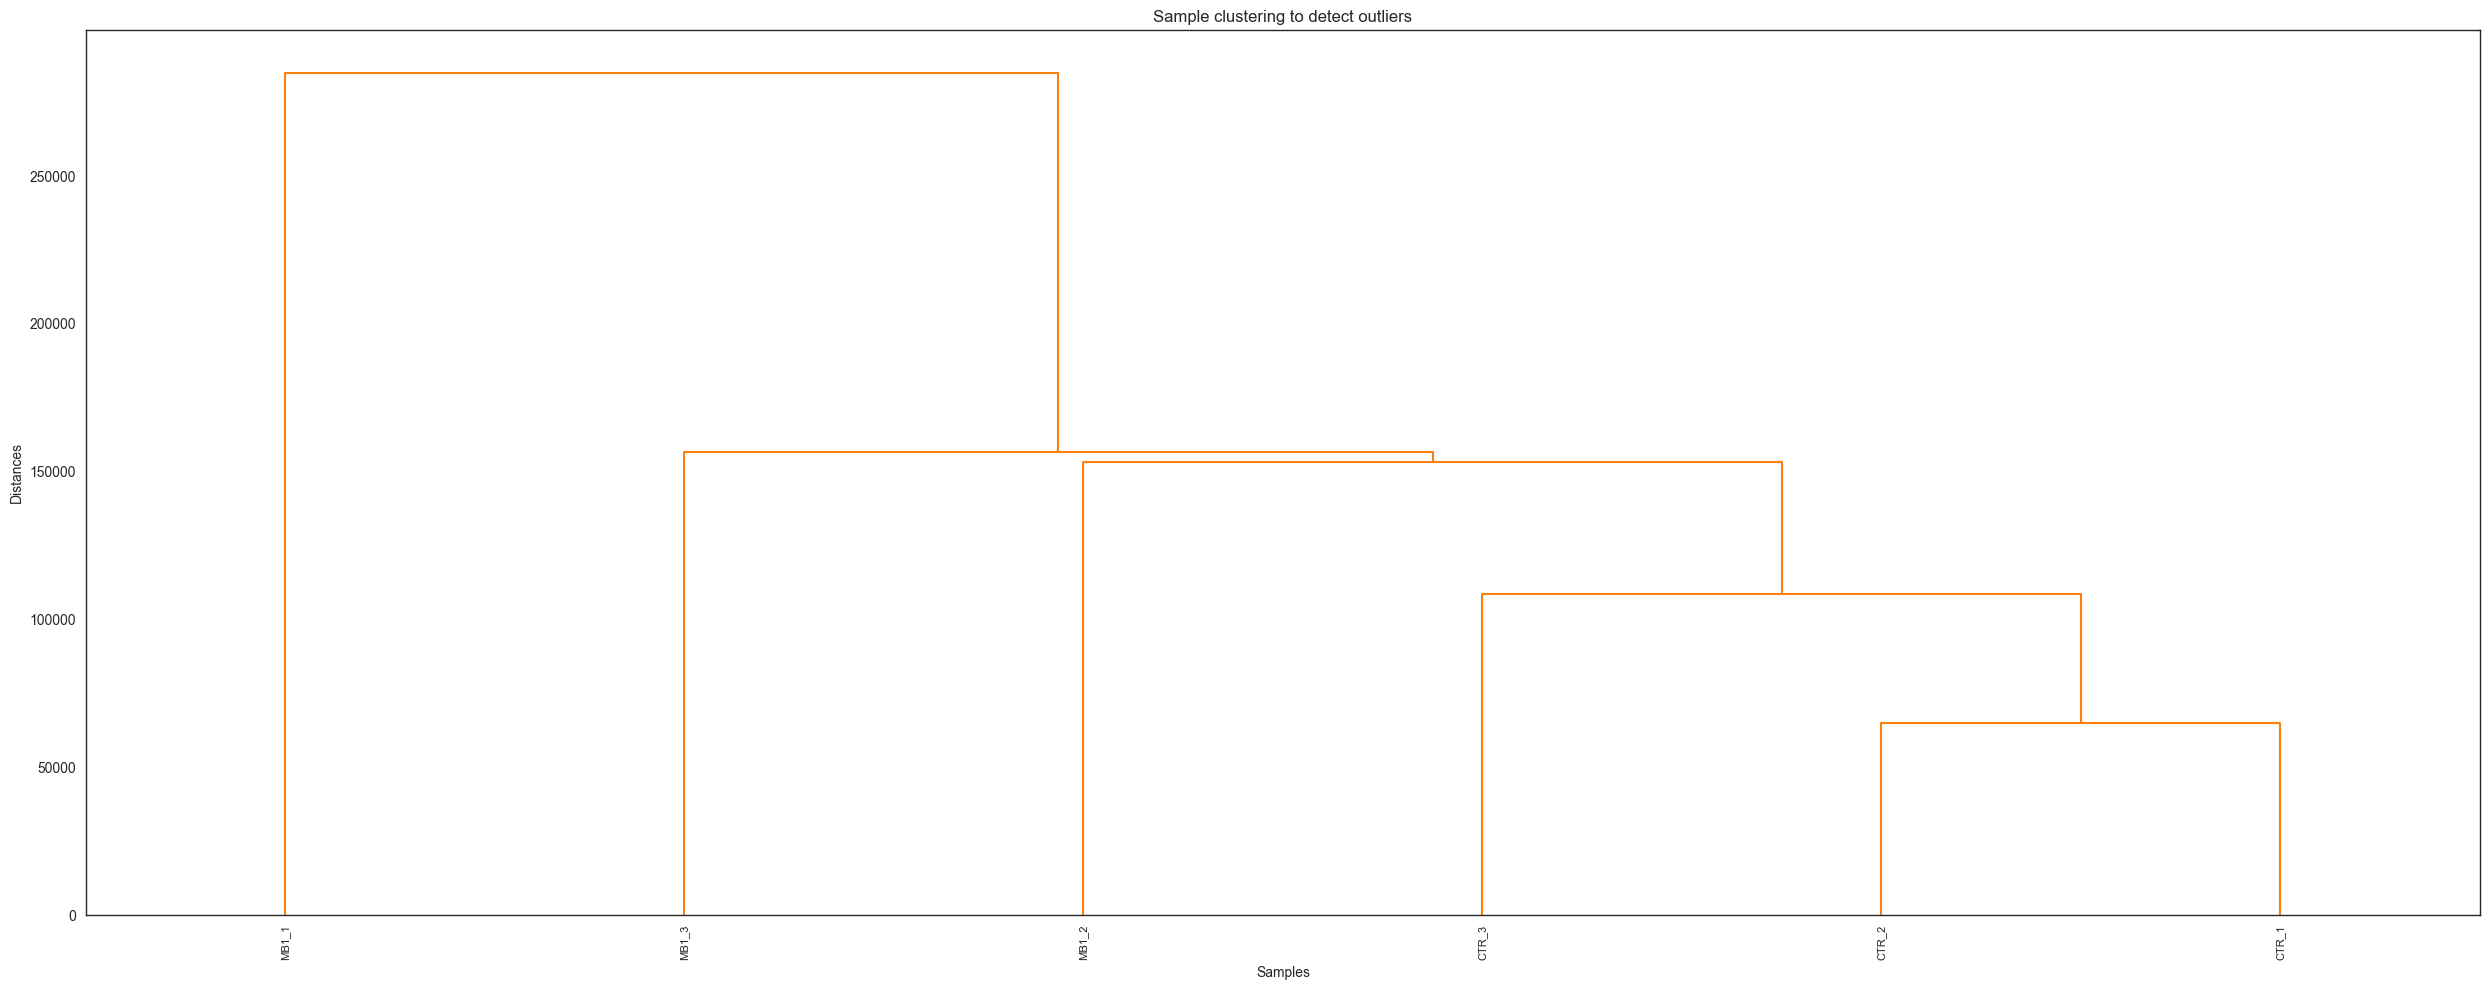

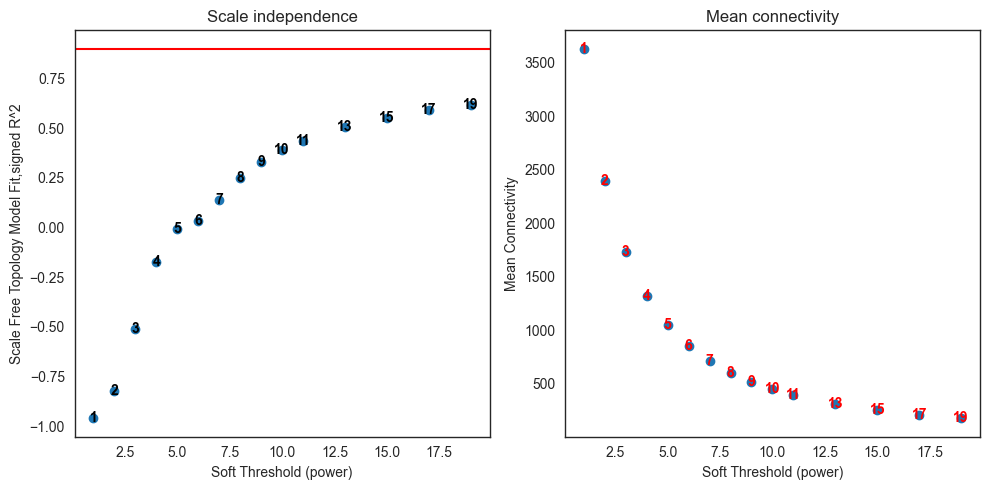

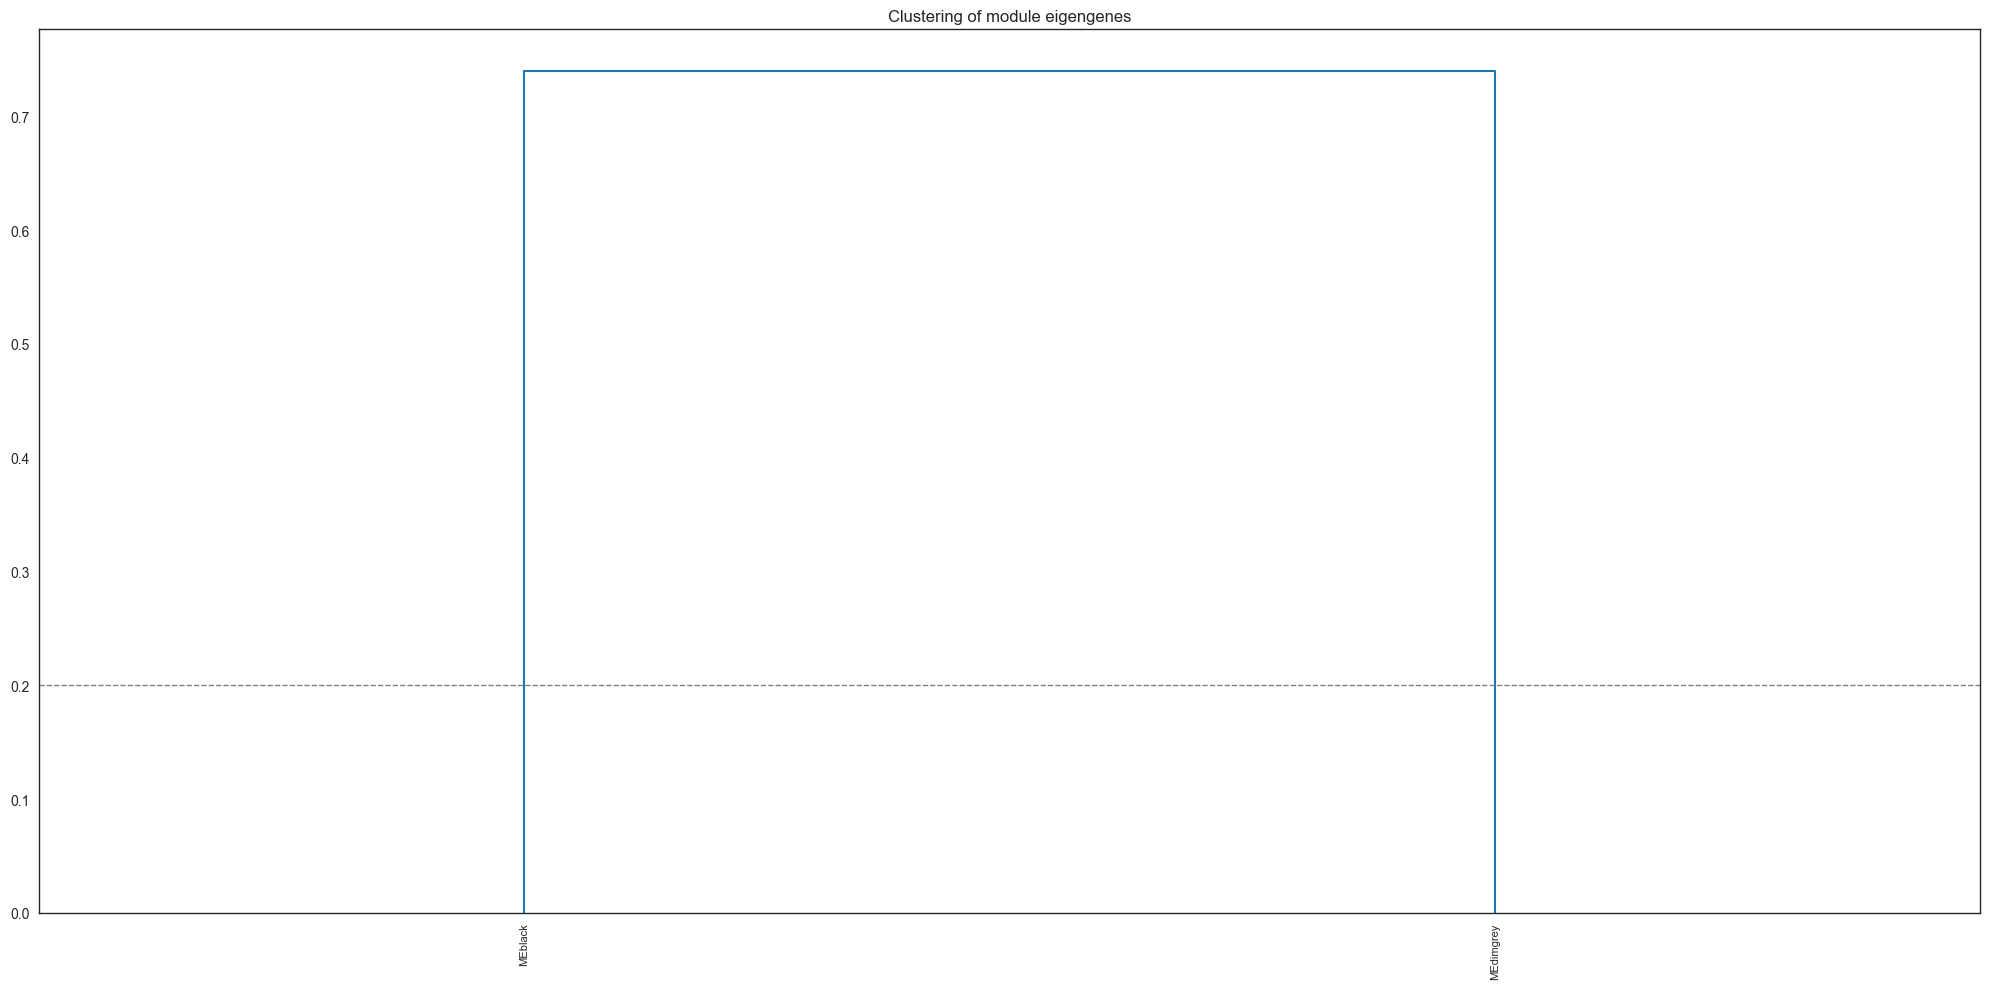

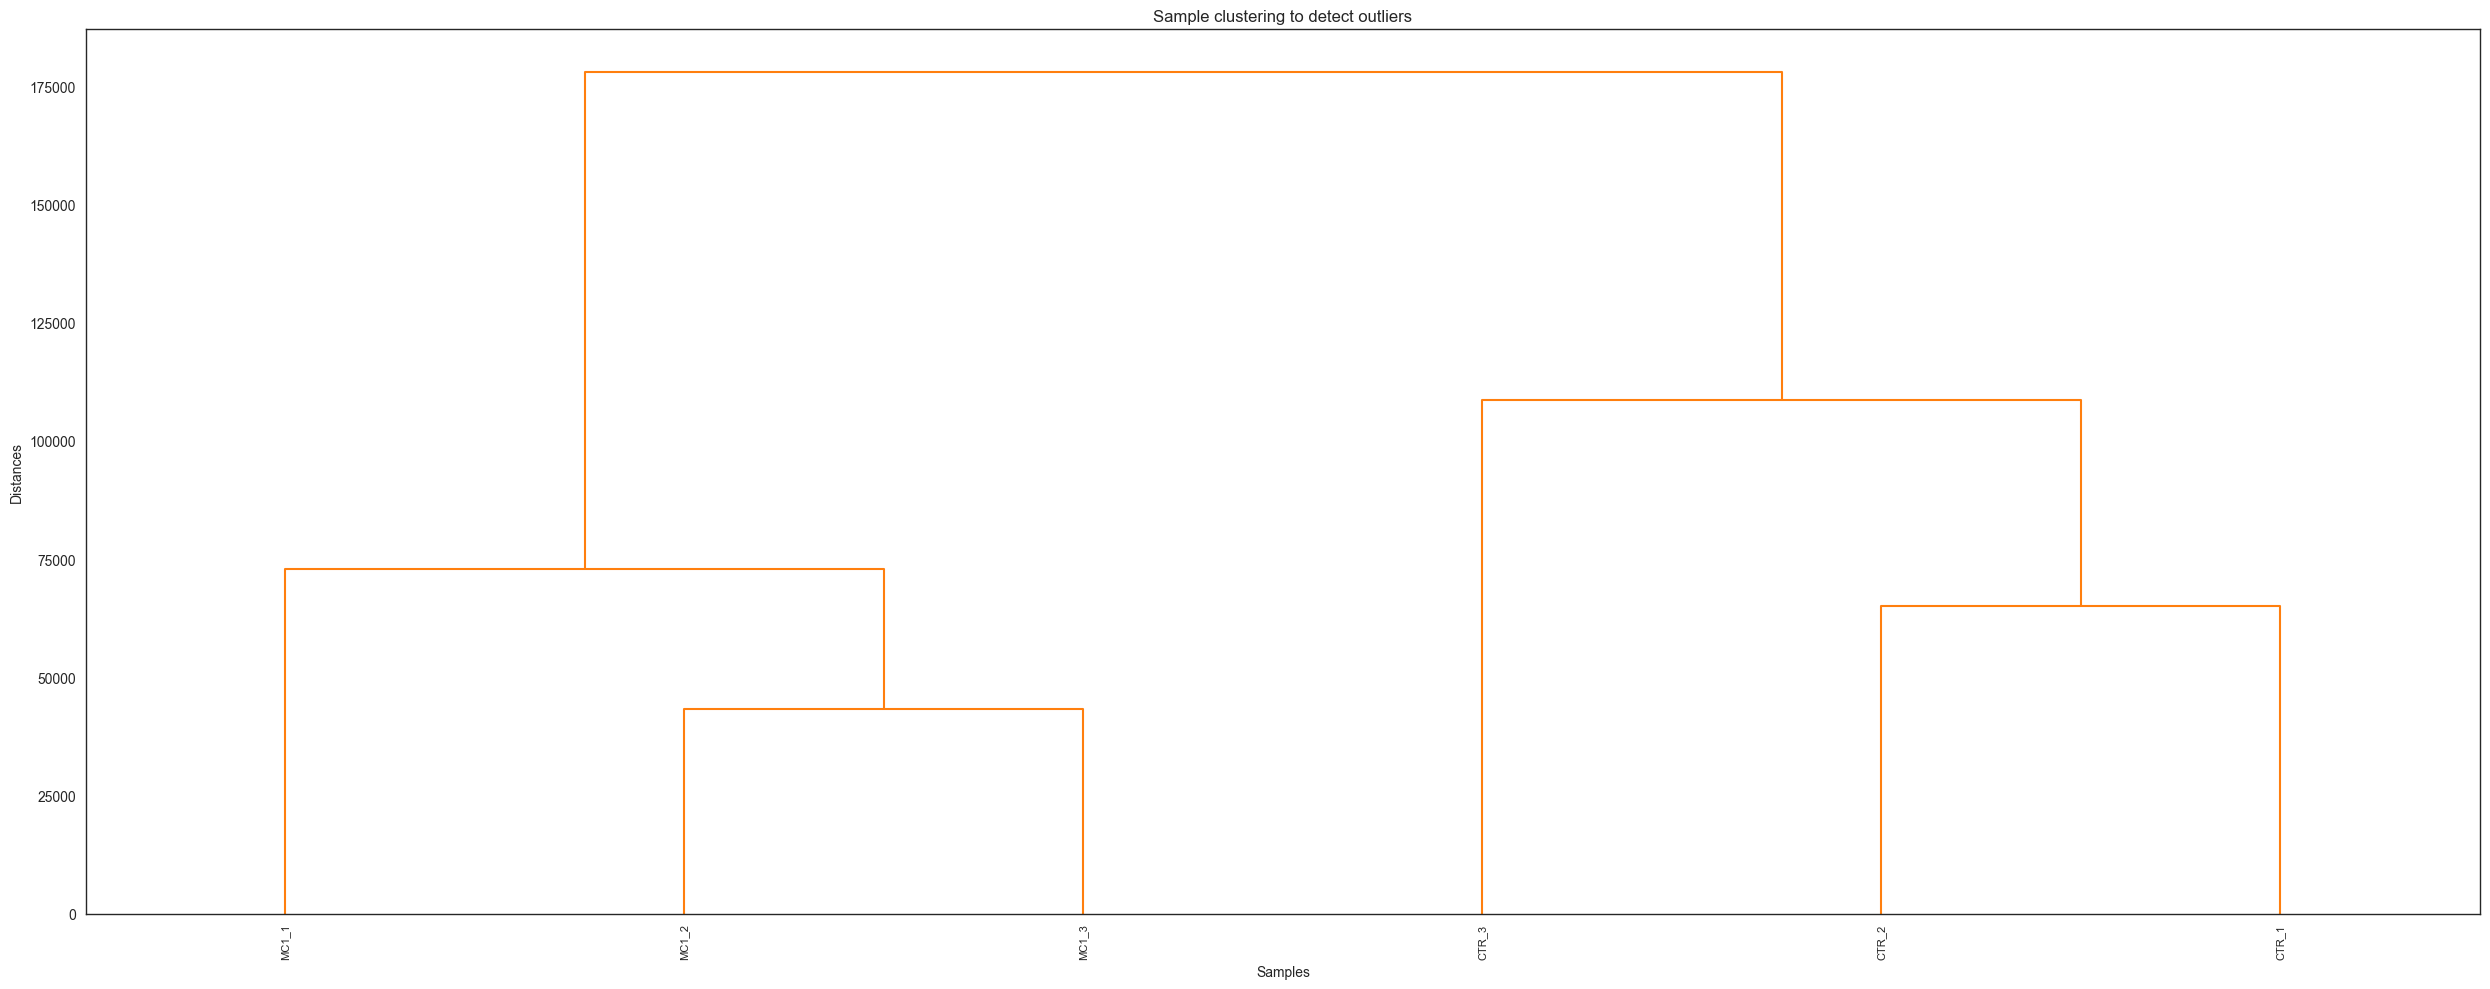

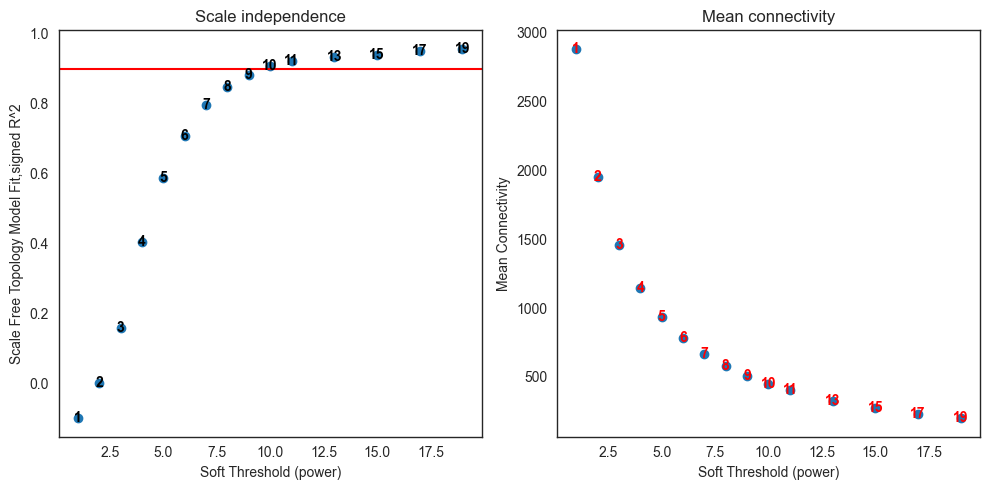

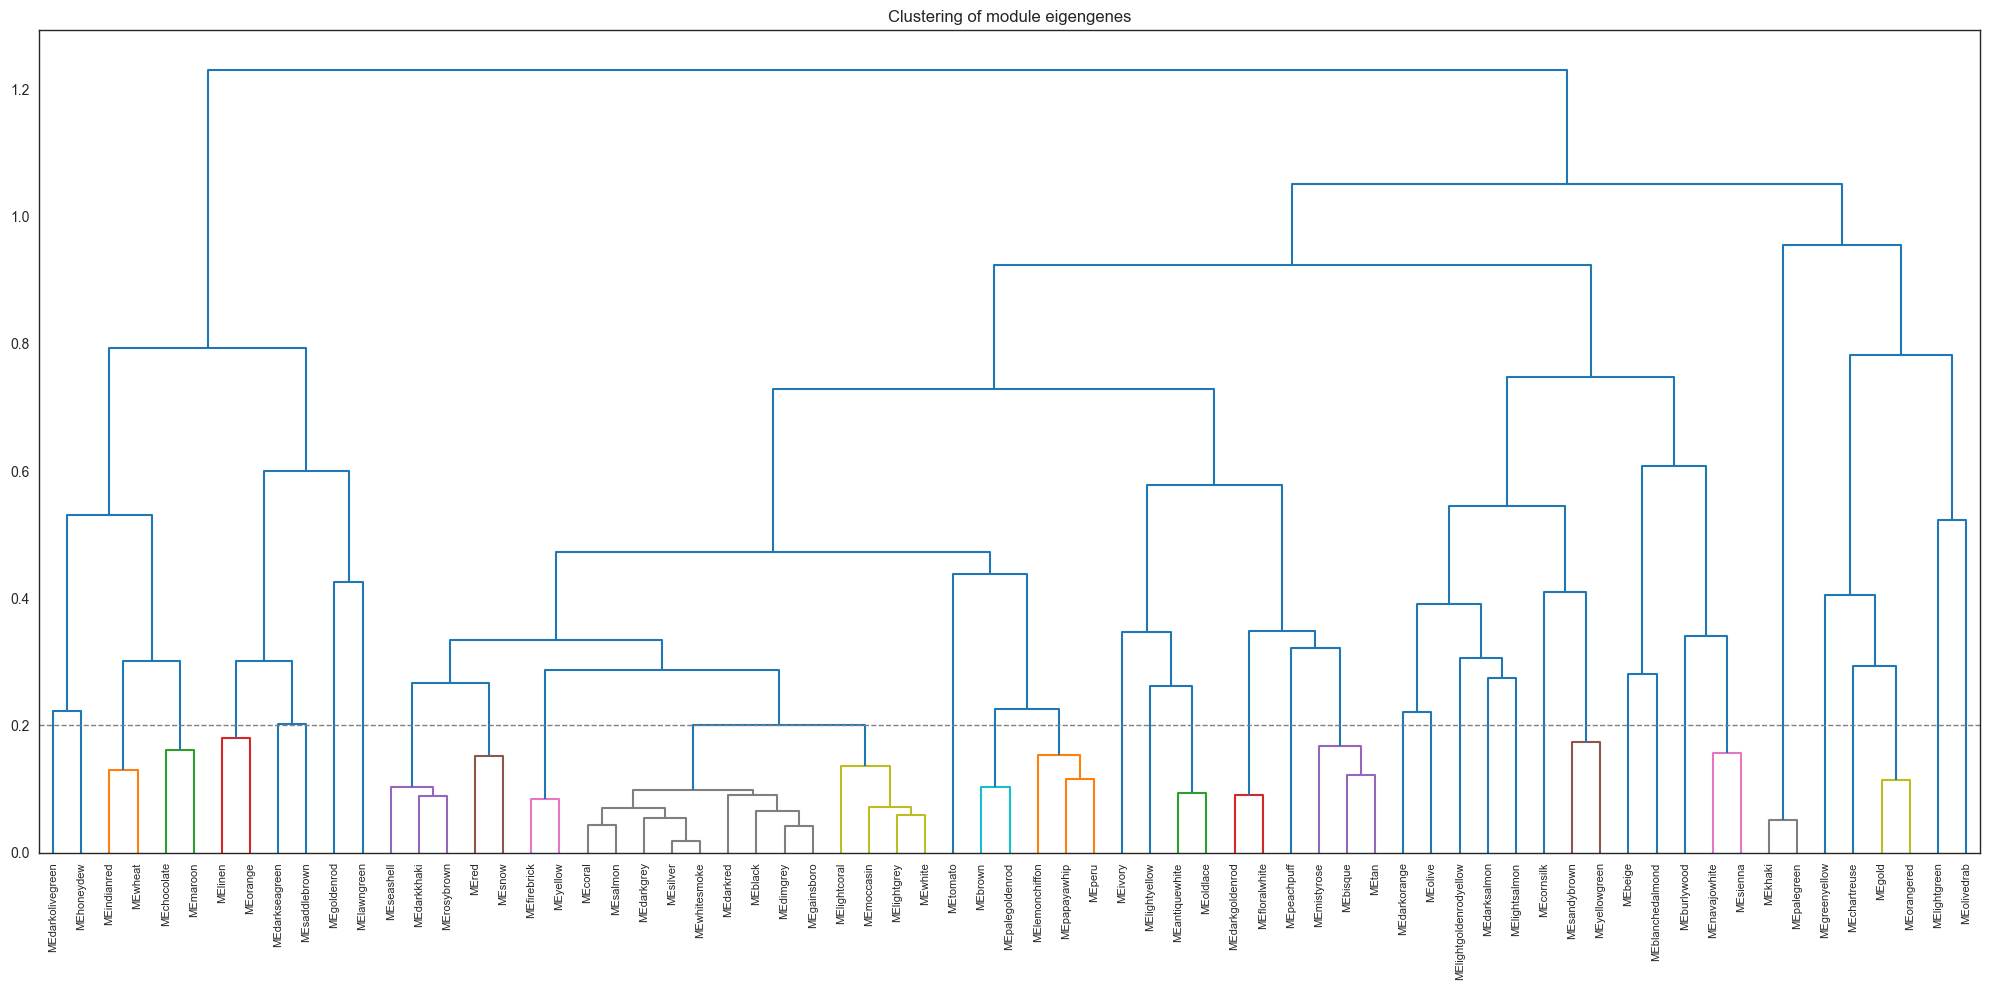

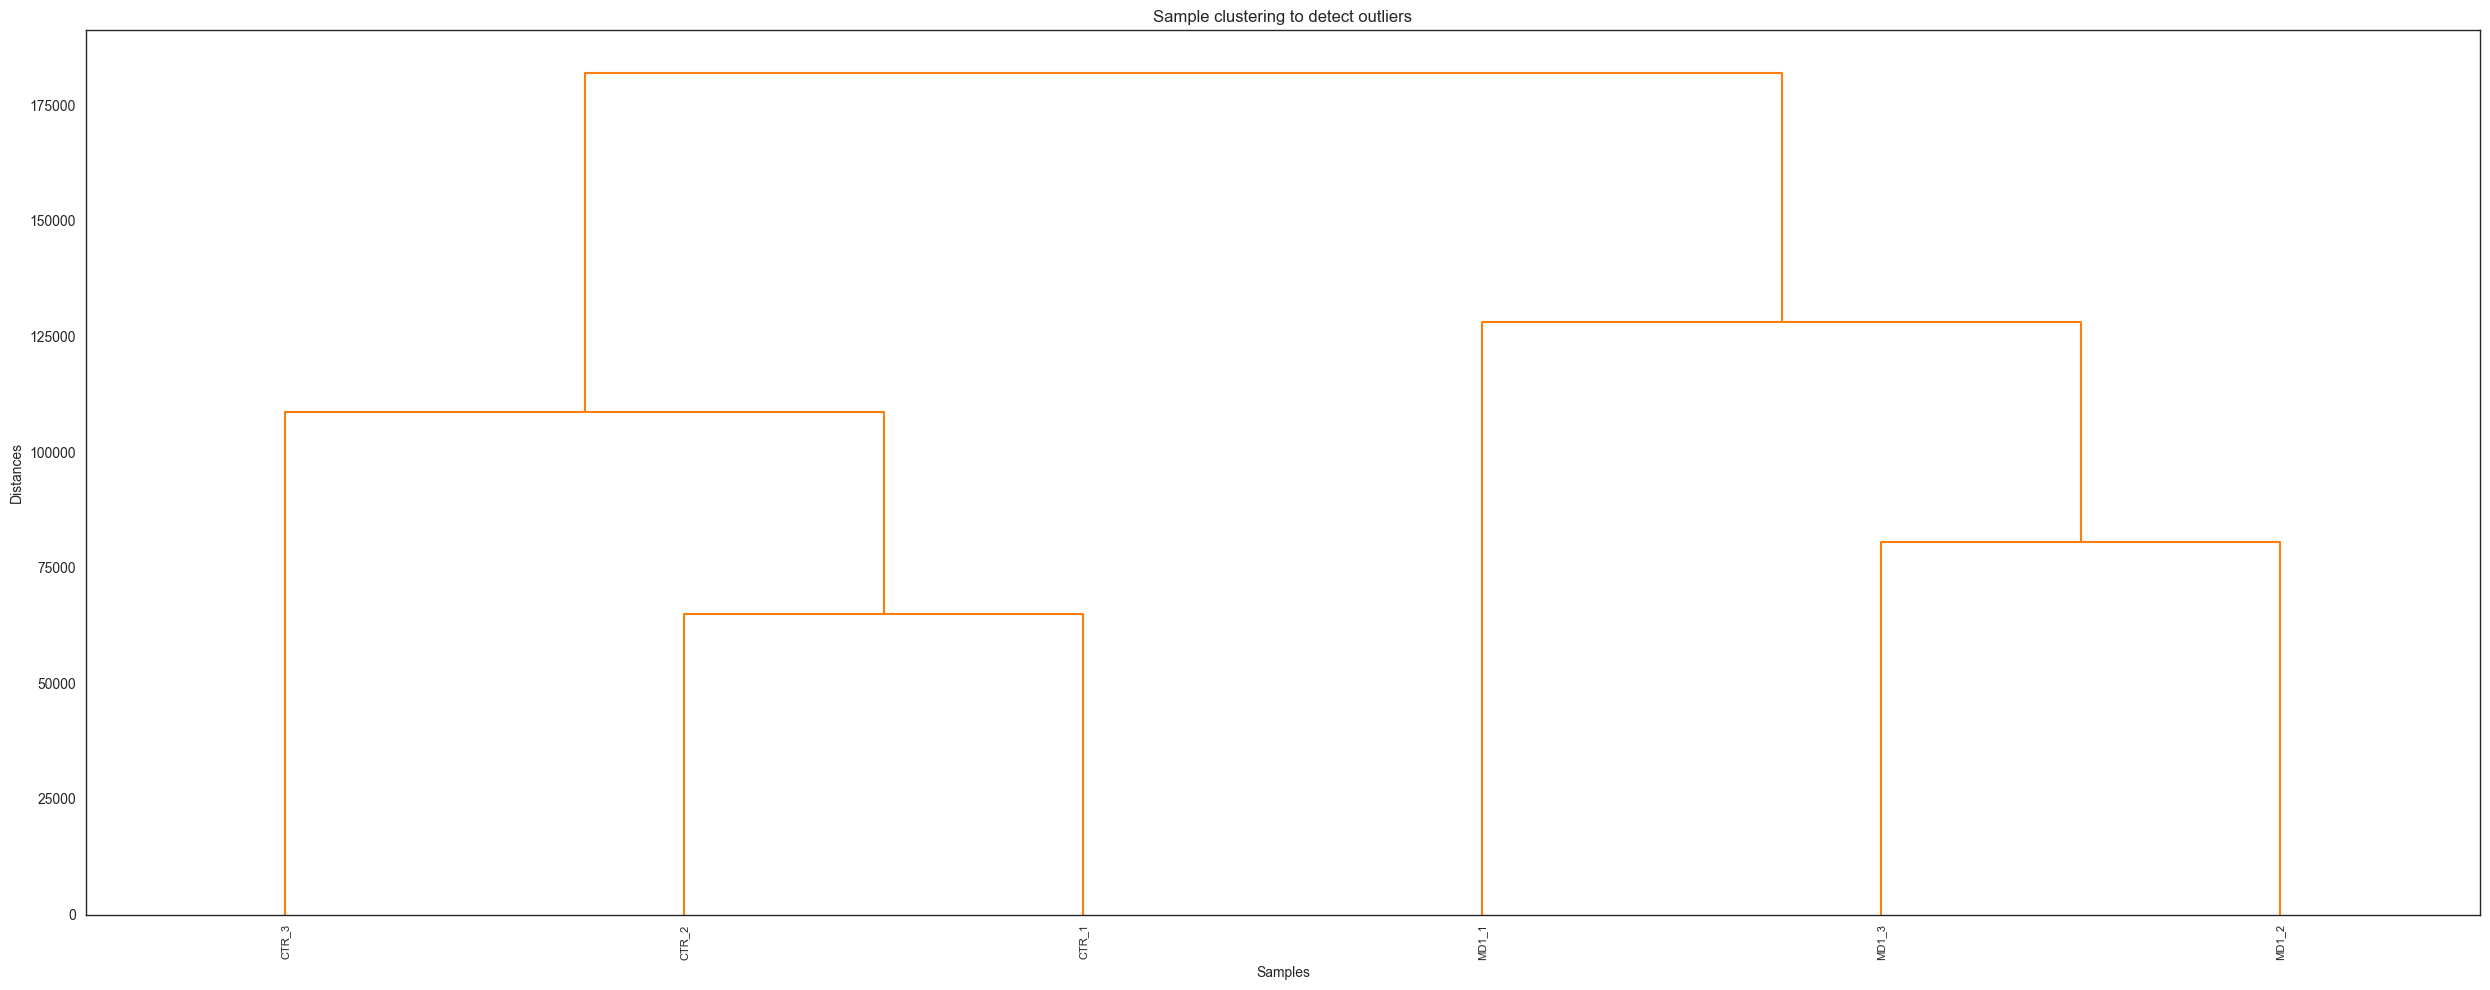

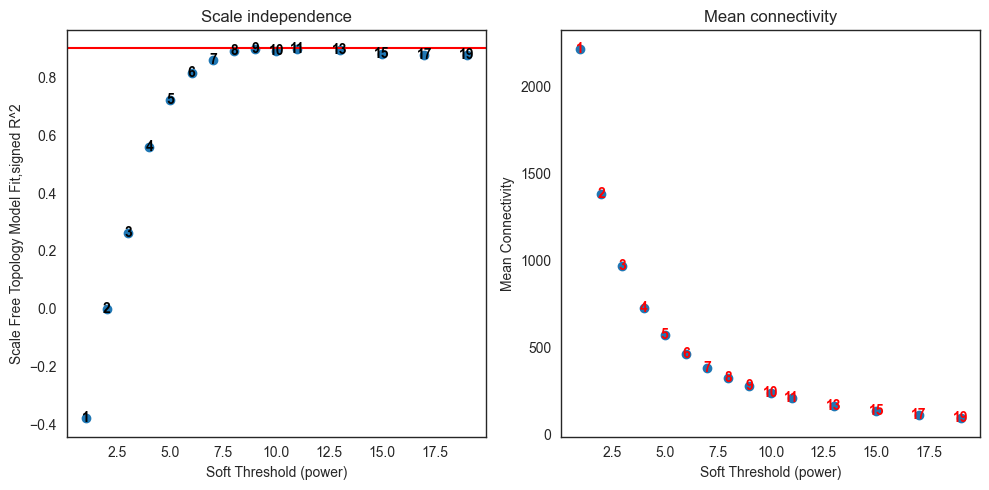

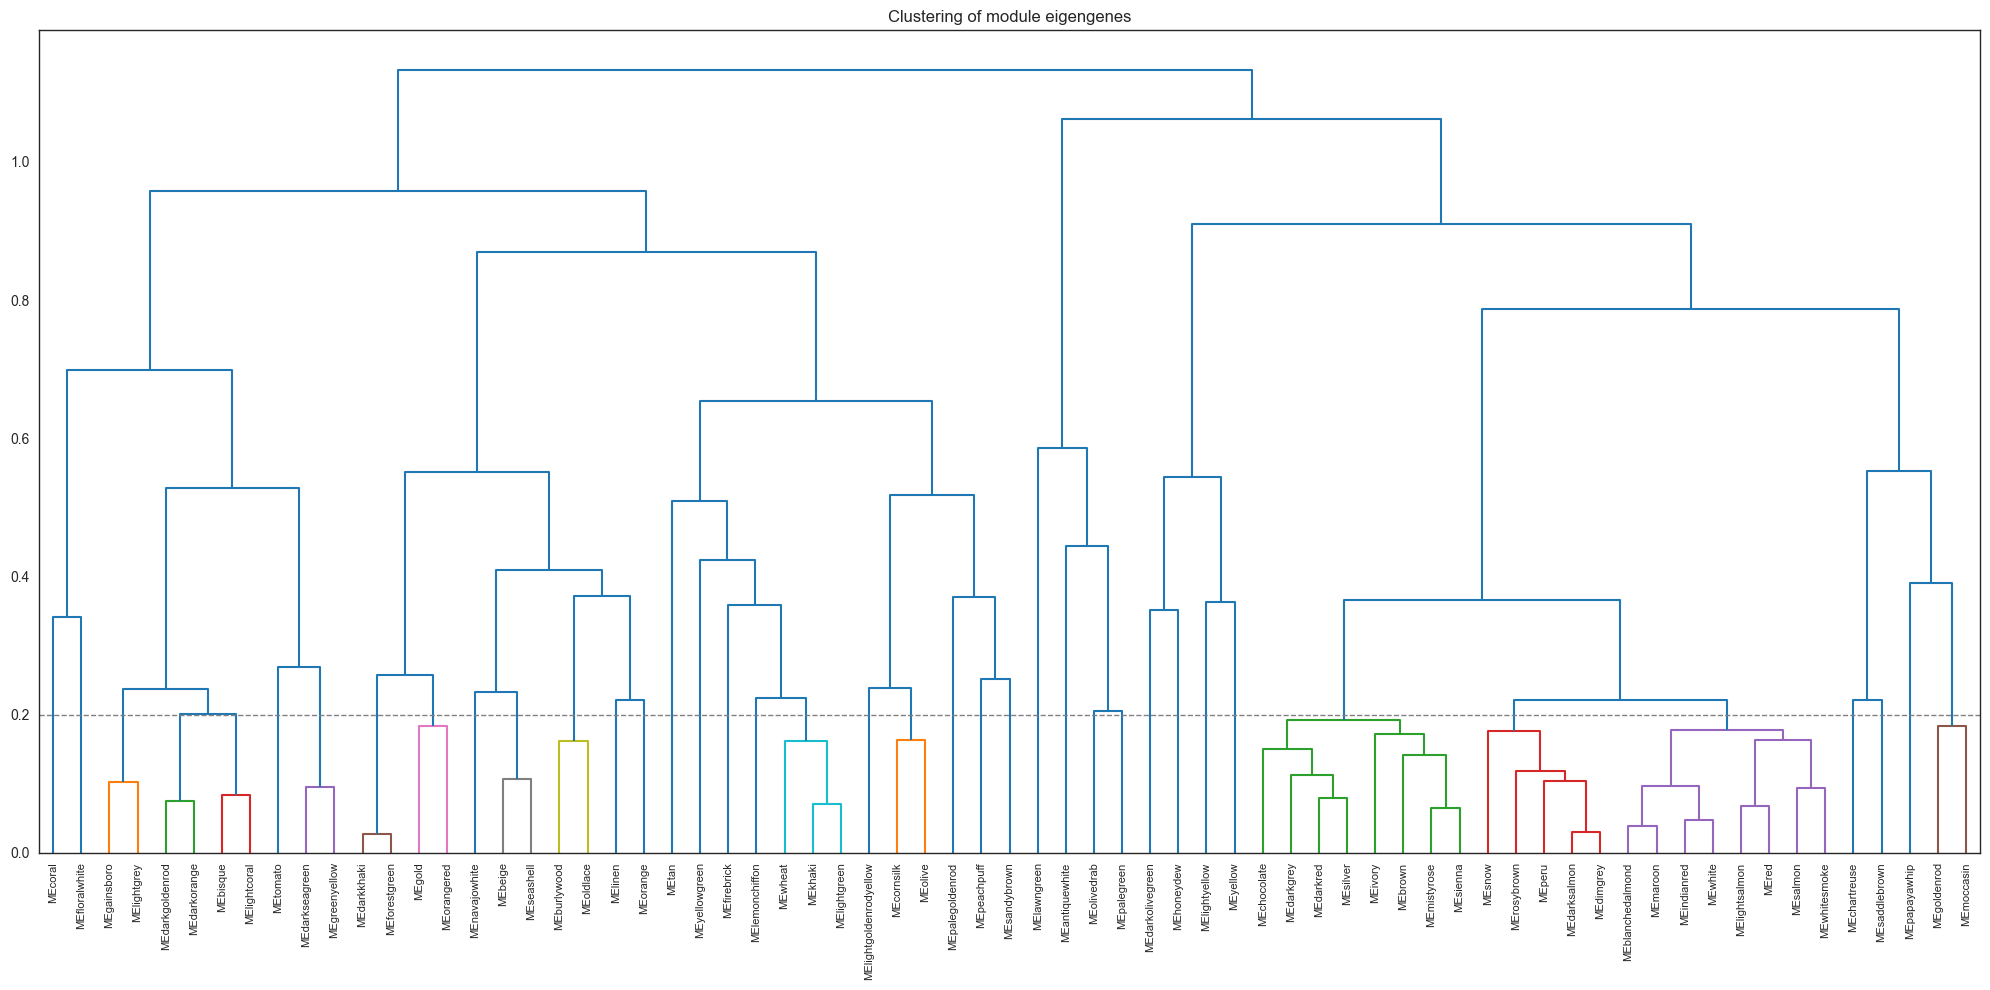

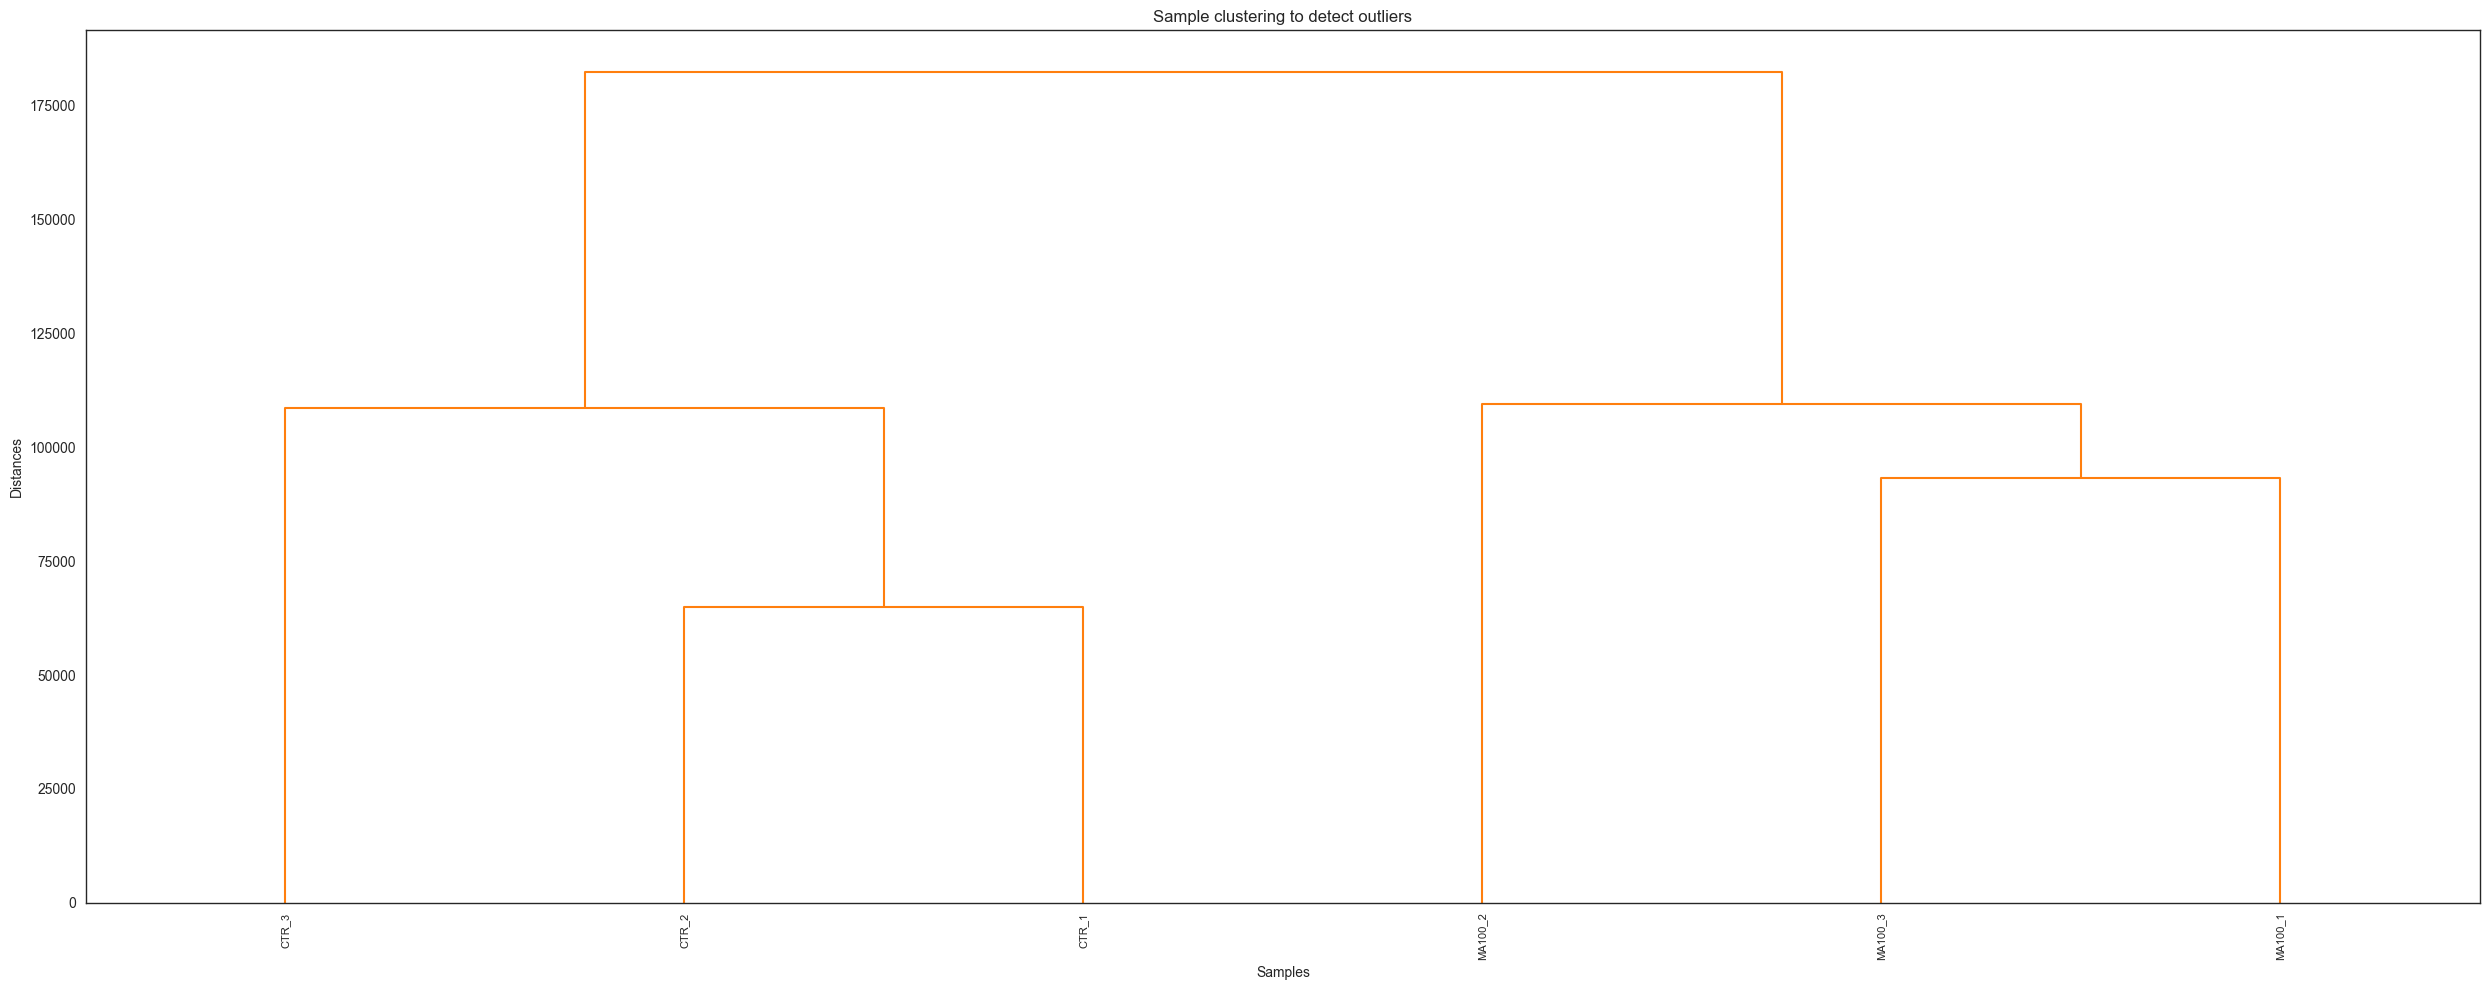

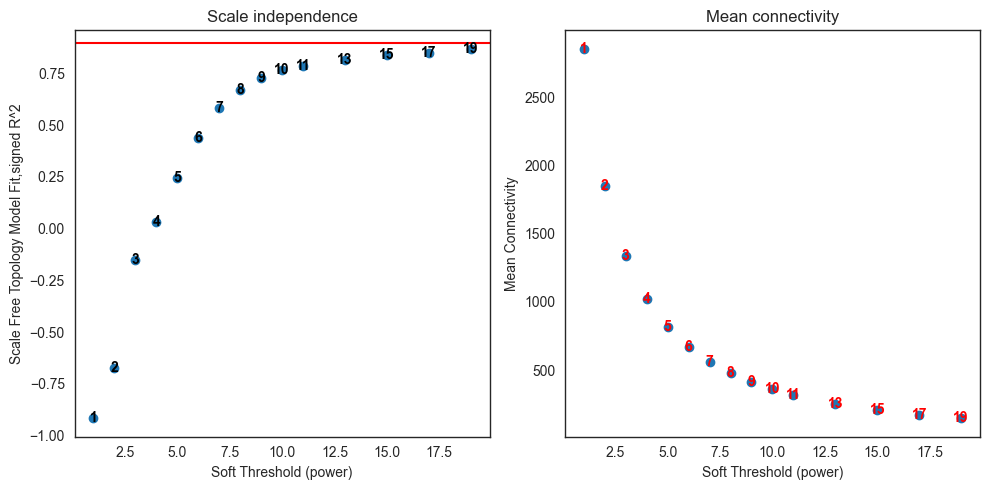

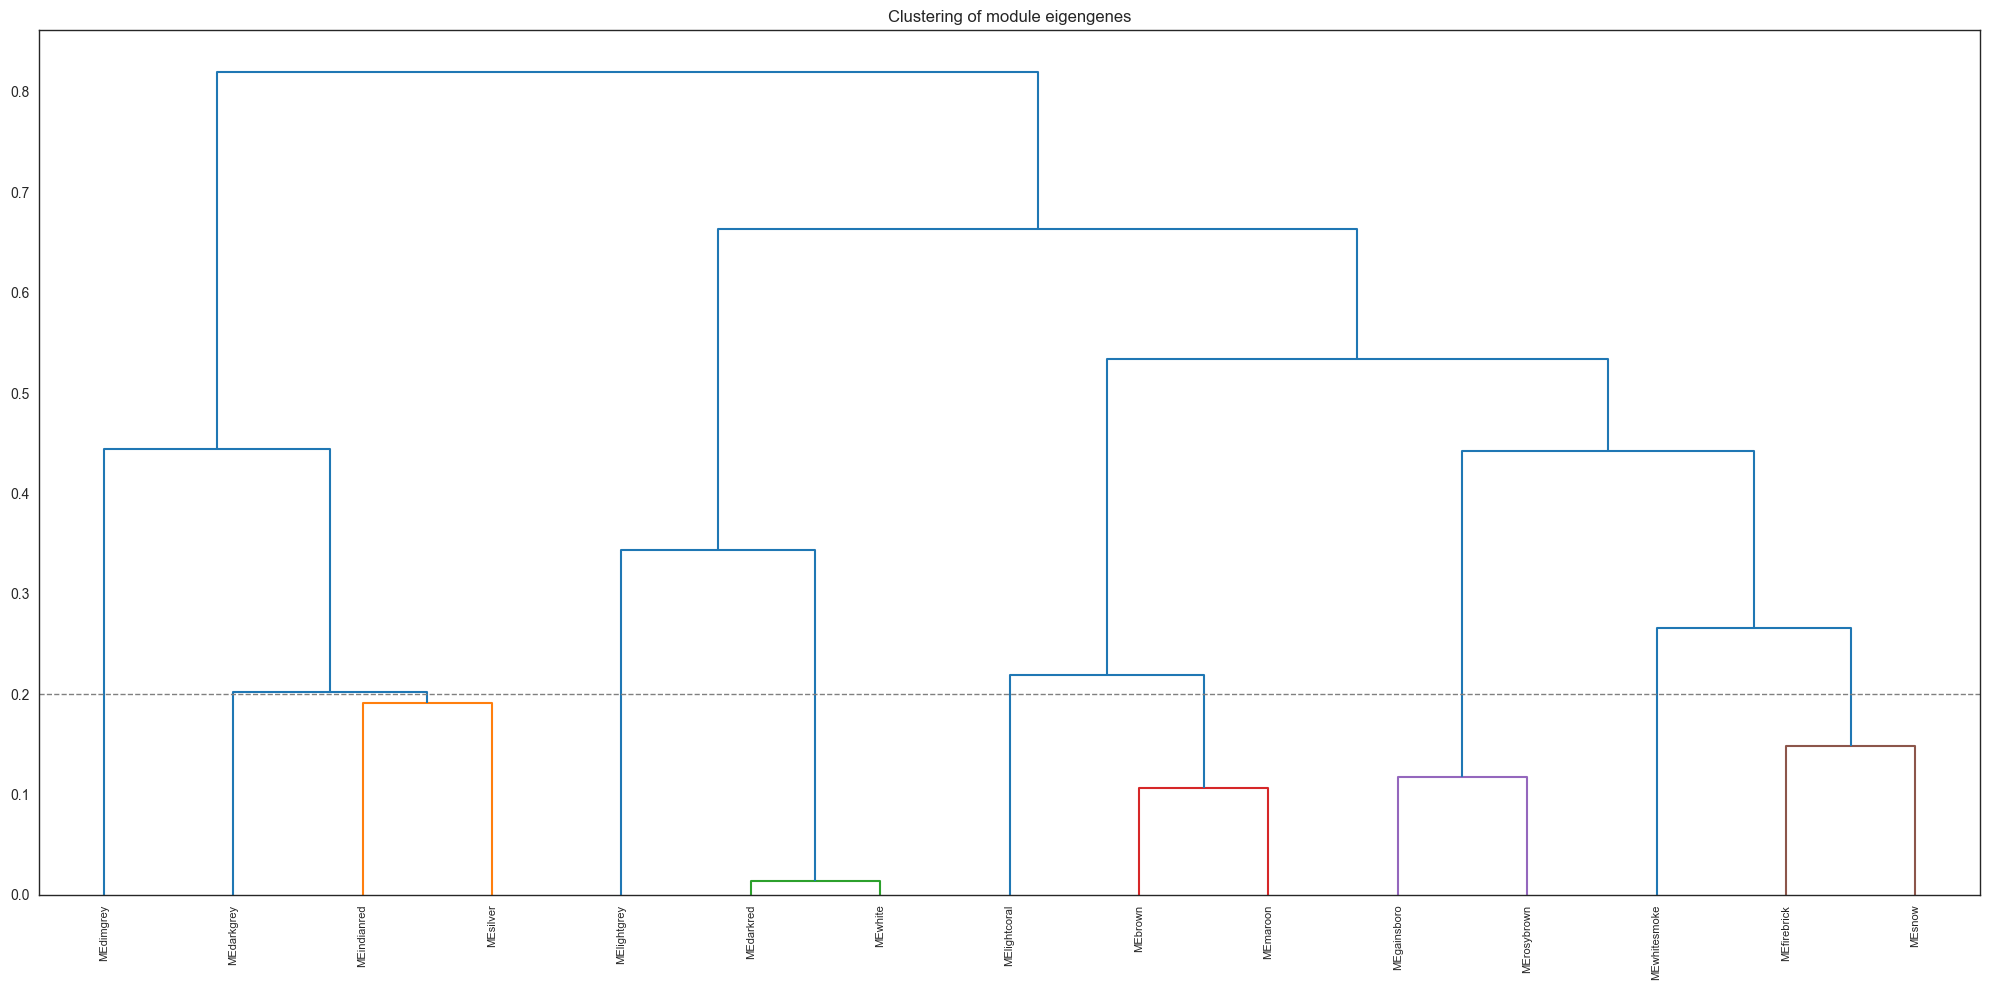

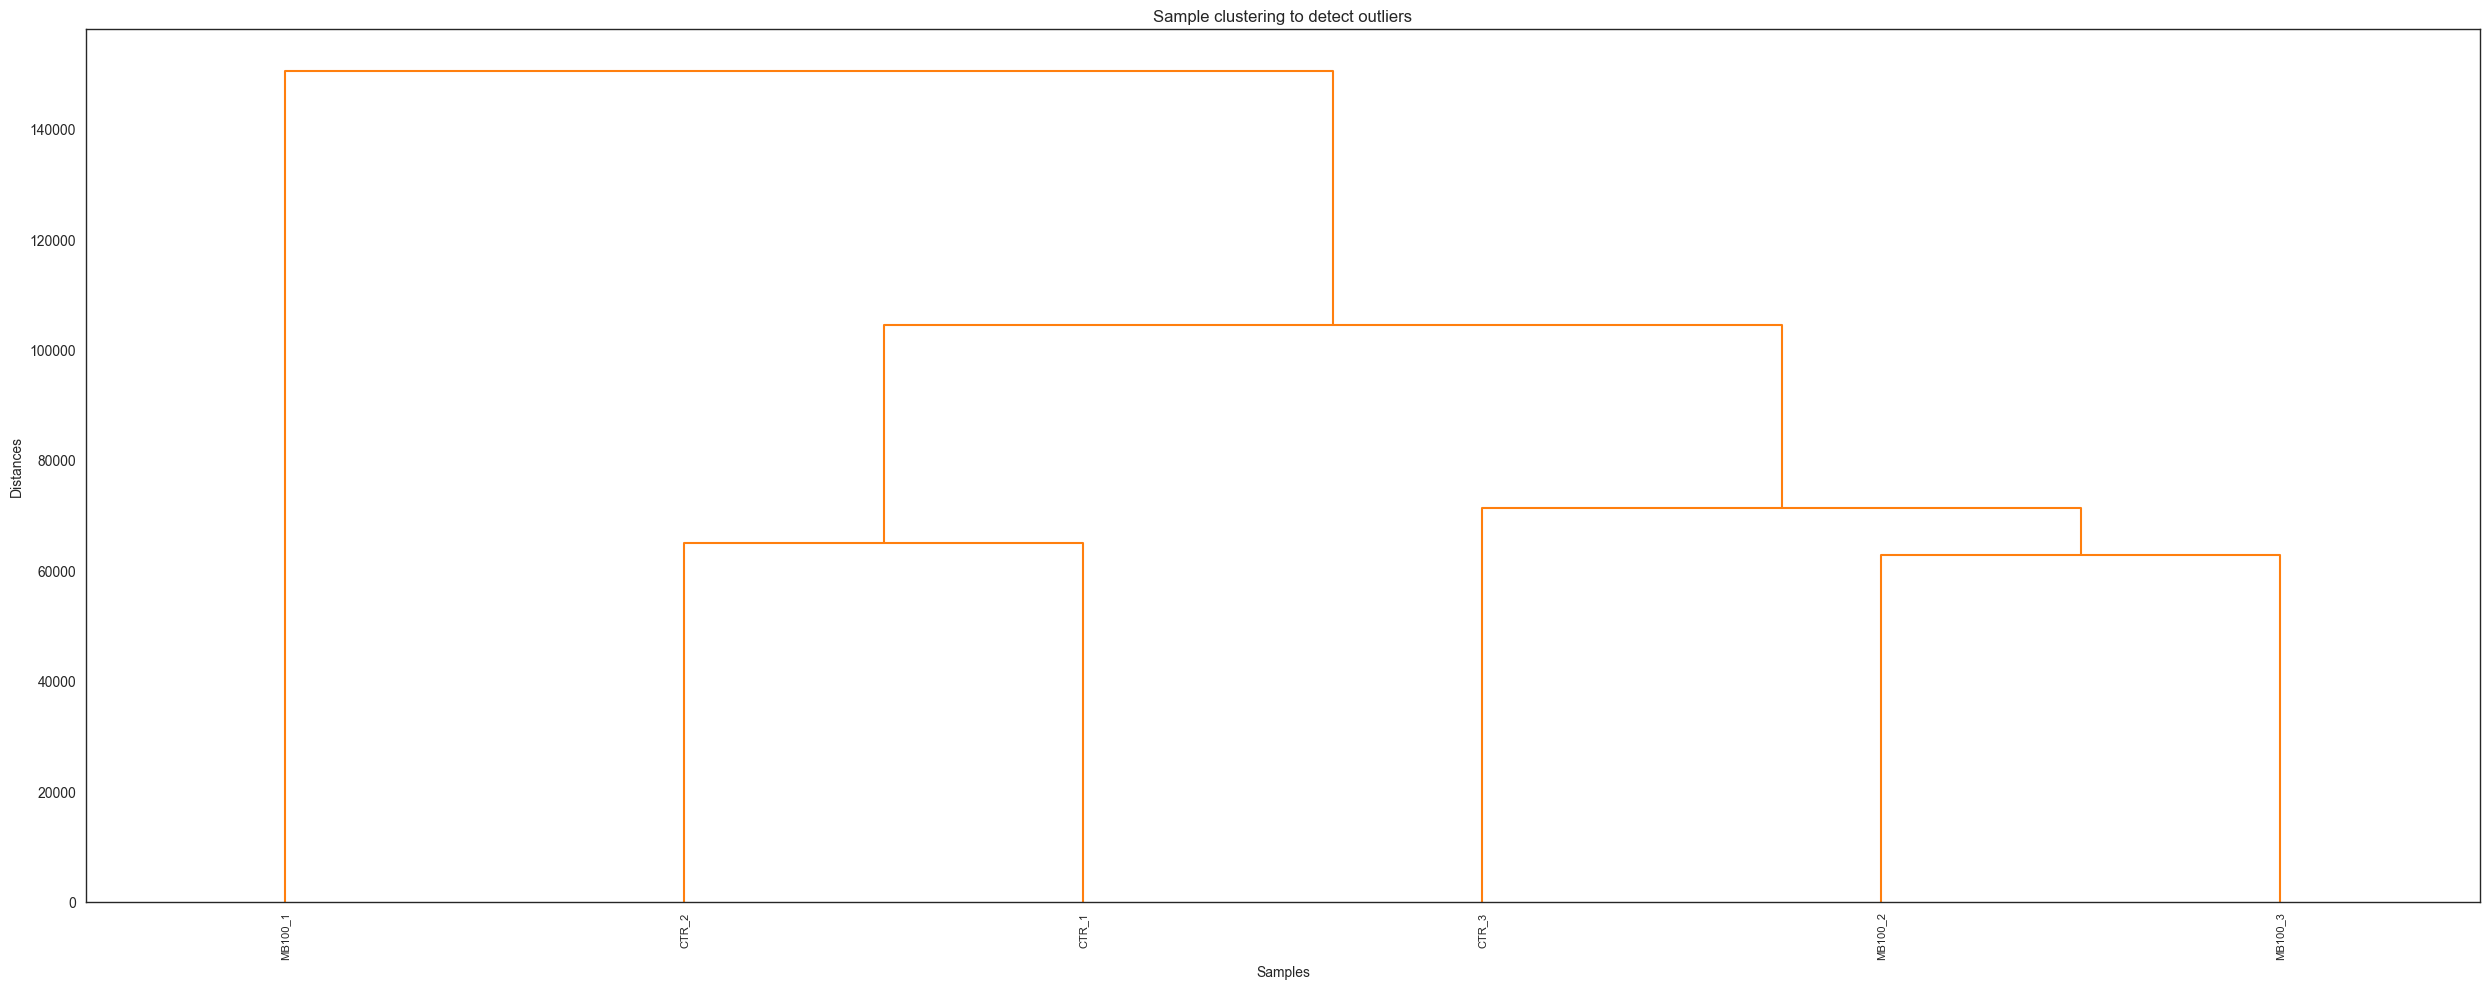

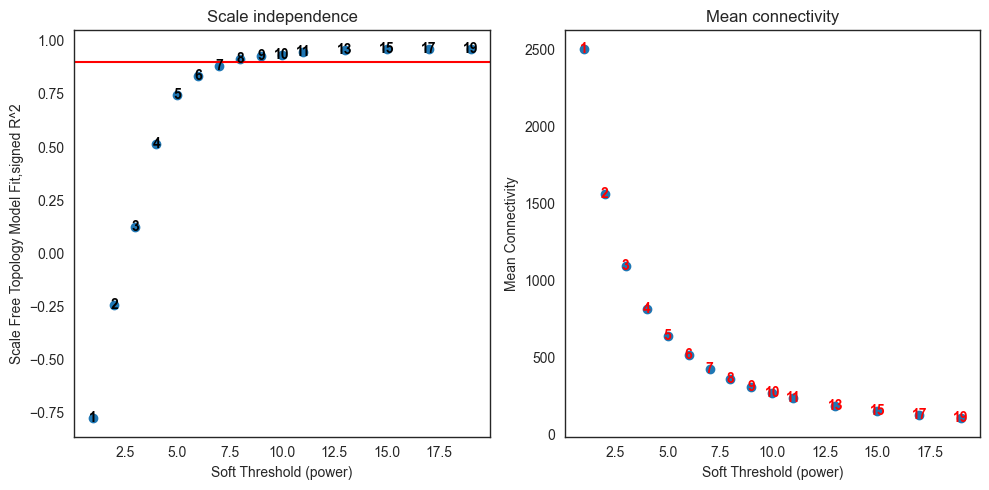

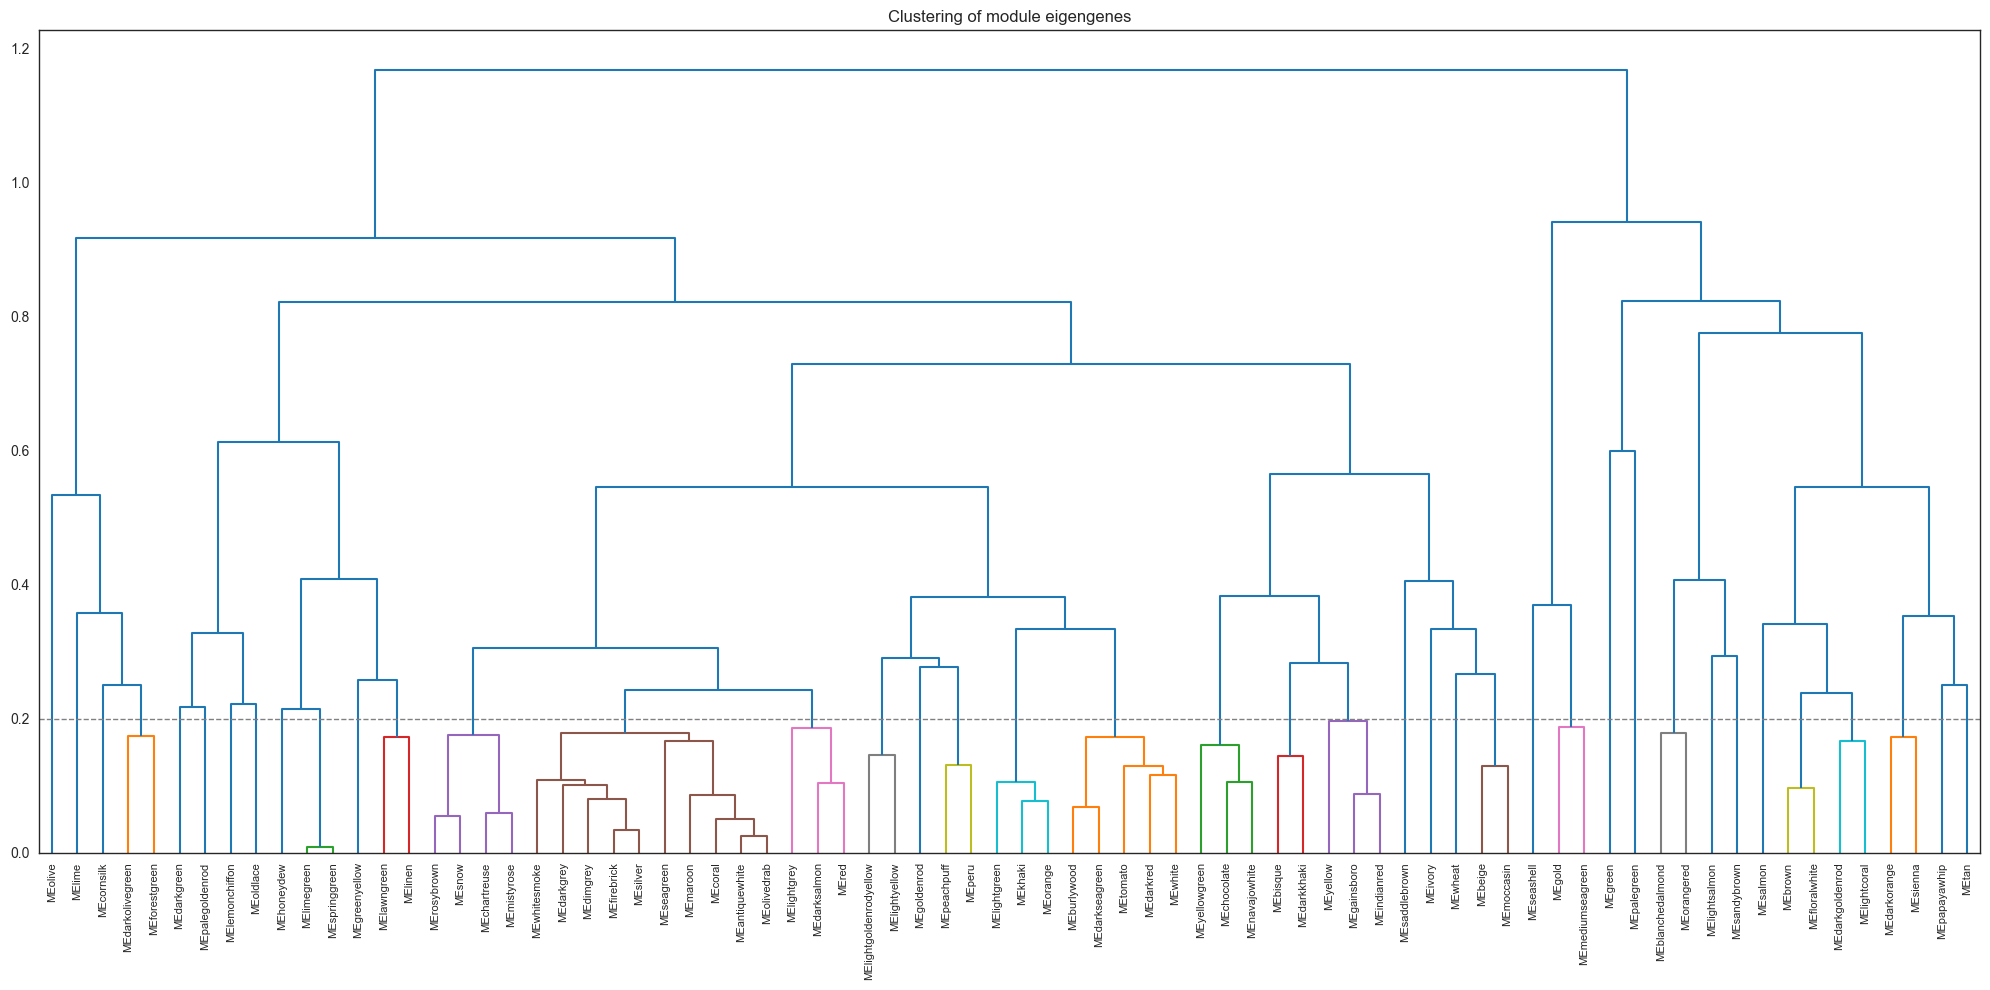

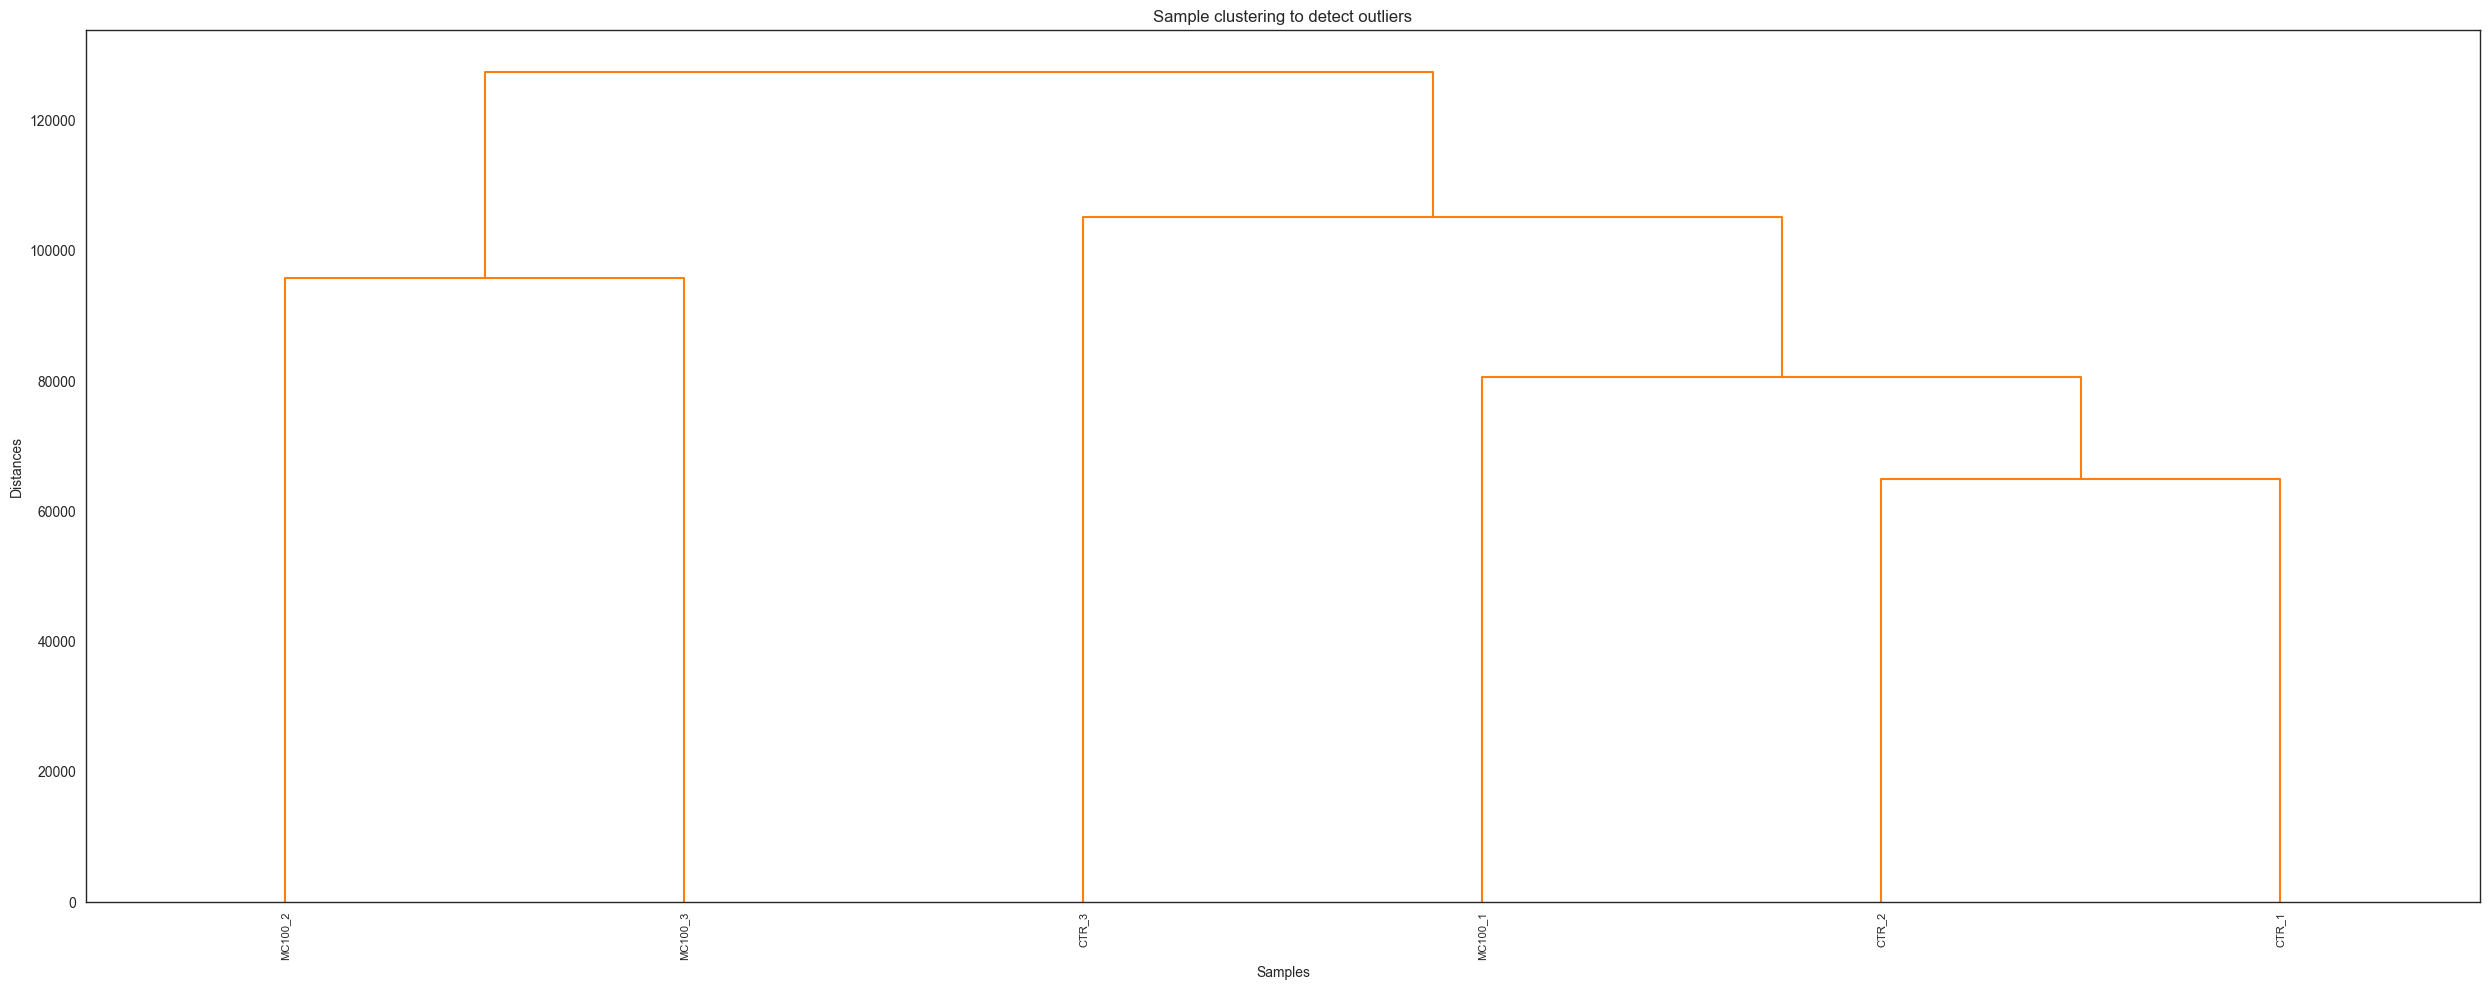

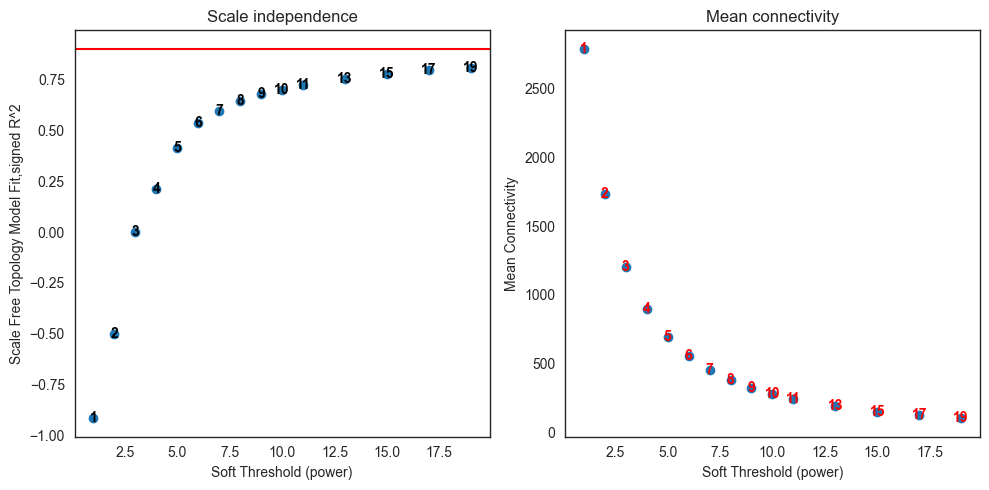

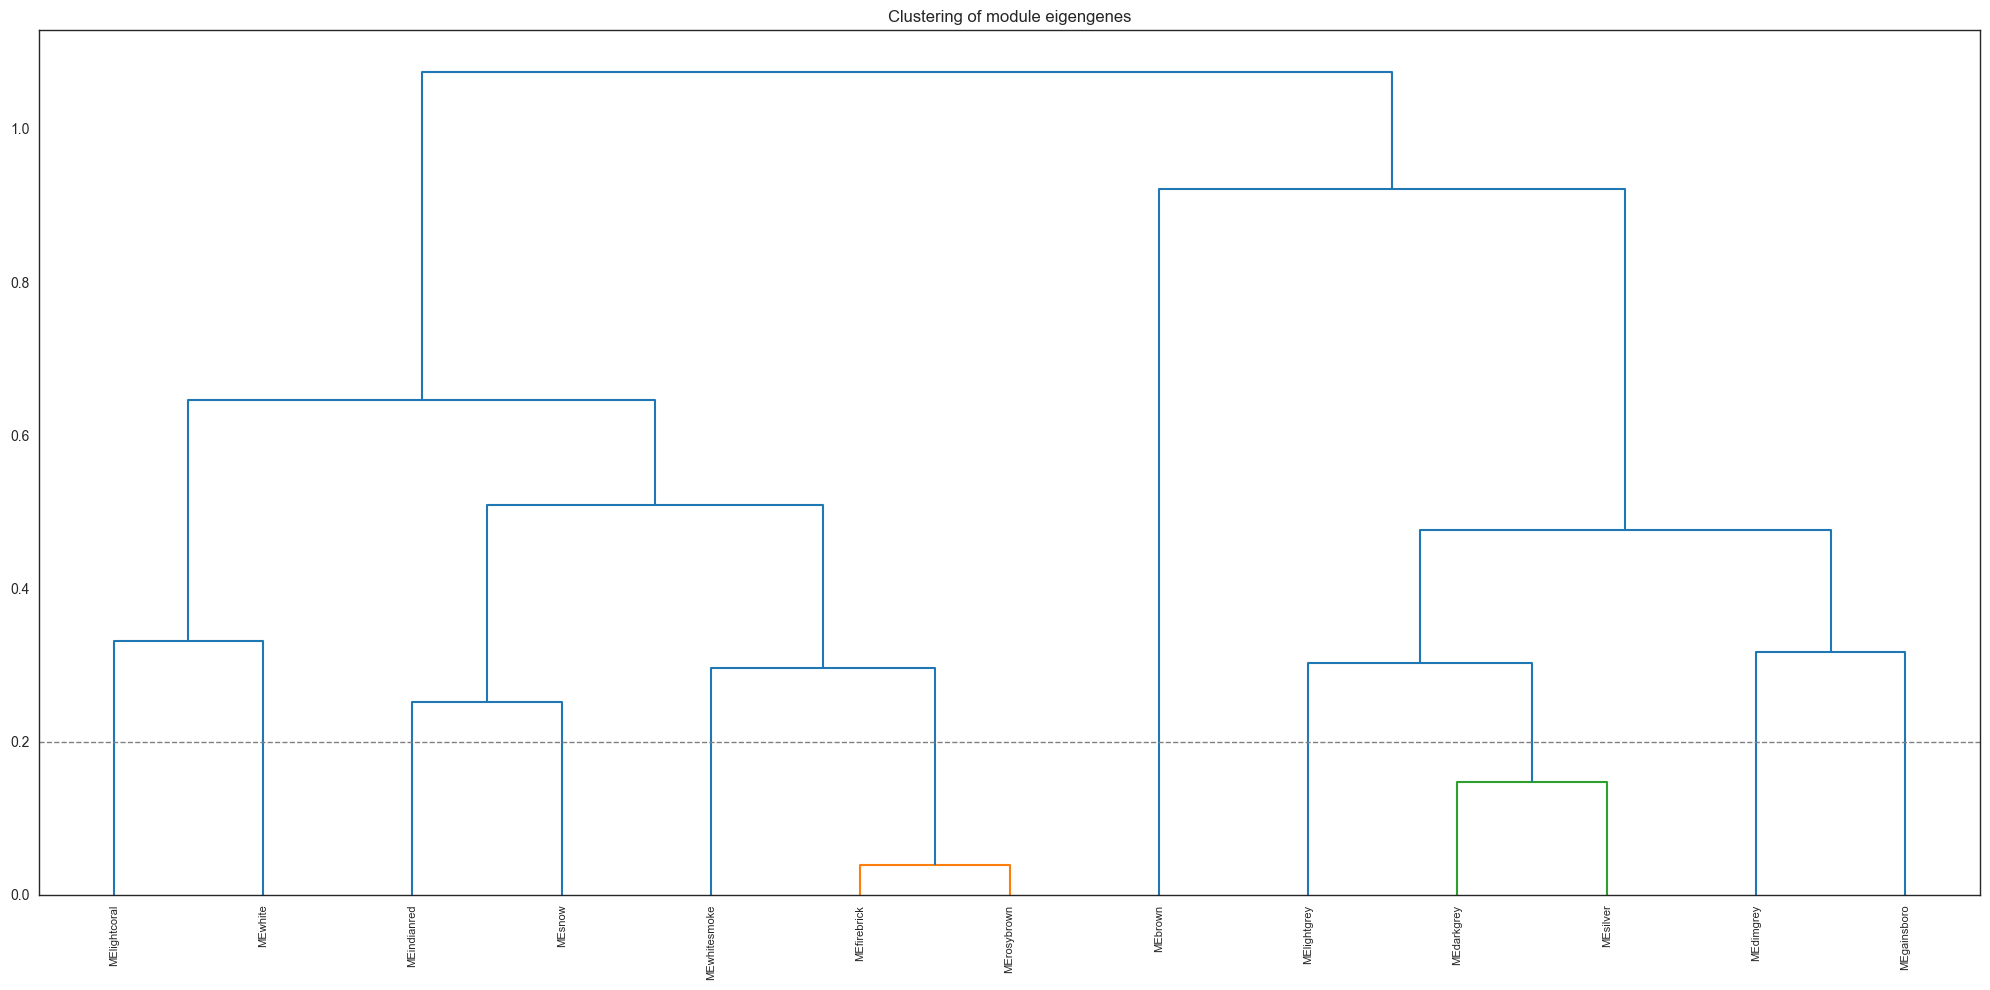

In [4]:
concentration_groups = ['MA1', 'MB1', 'MC1', 'MD1', 'MA100', 'MB100', 'MC100']

for concentration in concentration_groups:
    wgcna_result = metrics.run_pairwise_wgcna(geo_dataset_formated, treatment_prefix=concentration, control_prefix="CTR", top_n_genes=8000, output_csv_path=f"../../data/interim/wgcna_df_{concentration}.csv")
    io_transforms.save_module_gene_ids(wgcna_result, output_dir=f"../../data/interim/wgcna_modules/{concentration}_CTR/")


## Metrics without PyWGCNA

In [4]:
concentration_groups = ['MA1', 'MB1', 'MC1', 'MD1', 'MA100', 'MB100', 'MC100']

for concentration in concentration_groups:
    log2fc_result = metrics.calculate_log2fc(geo_dataset_formated, treatment_group=concentration, control_group="CTR")
    filtered_genes = metrics.filter_significant_genes(log2fc_result, target_column=f"Log2FC_{concentration}", threshold=1.0)
    
    print(f"Concentration: {concentration}, Significant Genes: {len(filtered_genes)}")
    save_path = f"../../data/interim/log2fc_filtered_results_{concentration}.csv"
    io_transforms.save_dataframe(filtered_genes['gene_id'], save_path)


Concentration: MA1, Significant Genes: 5918
Concentration: MB1, Significant Genes: 6440
Concentration: MC1, Significant Genes: 7317
Concentration: MD1, Significant Genes: 6708
Concentration: MA100, Significant Genes: 6989
Concentration: MB100, Significant Genes: 5885
Concentration: MC100, Significant Genes: 5825
